# LCDM - Inspect emulators results

In [1]:
root = '/ceph/hpc/data/s25r06-05-users/test/hub_f4_d2'

## Init

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import yaml
from tabulate import tabulate
import emu_like.io as io
from emu_like.ffnn_emu import FFNNEmu

2026-04-10 13:51:43.877436: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-10 13:51:43.881760: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-10 13:51:43.893392: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775821903.911659 2321905 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775821903.917204 2321905 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775821903.931768 2321905 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [10]:
class EmuData(object):

    def __init__(self, path):
        self.name = os.path.basename(path)
        self.emu = FFNNEmu()
        self.emu.load(path, still_training=False)
        self.abs_diff = None
        self.rel_diff = None
        self.mean_abs_diff = None
        self.mean_rel_diff = None
        pass

    def _scale_x(self, x):
        return self.emu.x_scaler.transform(x)

    def _scale_y(self, y):
        return self.emu.y_scaler.transform(y)

    def _inverse_scale_x(self, x):
        return self.emu.x_scaler.inverse_transform(x)

    def _inverse_scale_y(self, y):
        return self.emu.y_scaler.inverse_transform(y)

    def _pca_x(self, x):
        return self.emu.x_pca.transform(x)

    def _pca_y(self, y):
        return self.emu.y_pca.transform(y)

    def _inverse_pca_x(self, x):
        return self.emu.x_pca.inverse_transform(x)

    def _inverse_pca_y(self, y):
        return self.emu.y_pca.inverse_transform(y)

    def get_y_emu(self, x, want_scaling=False, want_pca=False, select_pca_modes=None, timeit=False):
        """
        From the emulator we get y that are potentially scaled and PCA
        applied. However, it is possible that just one or none of them
        are used. Errors are implemented for incompatible requests:
        Arguments:
        - x (array): 1-2D array for the x that should be emulated;
        - want_scaling (bool, default: False): want the results scaled or in the original units;
        - want_pca (bool, default: False): want the results in PCA space or not;
        - select_pca_modes (list, default: None): if list select the listed modes in PCA space.
        """

        if timeit:
            start_all = time.time()

        # Flags
        has_pca = self.emu.y_pca is not None
        has_scaling = self.emu.y_scaler is not None
        want_pca_selection = select_pca_modes is not None

        n_samples = x.shape[0]

        # Validate requested configuration
        if want_scaling and not has_scaling:
            raise ValueError('Cannot keep scaled units: y is already unscaled.')
        if want_pca and not has_pca:
            raise ValueError('Cannot request PCA output: emulator has no PCA transform.')
        if want_pca_selection and not has_pca:
            raise ValueError('Cannot select PCA modes: emulator has no PCA transform.')
        if want_pca and has_scaling and not want_scaling:
            raise ValueError('Cannot stay in PCA space while undoing scaling when PCA was built on scaled data.')

        # 1) Adjust x
        # Adjust dimensions x array
        if x.ndim == 1:
            x = x[np.newaxis, :]
        # Scale x
        if self.emu.x_scaler is not None:
            x = self._scale_x(x)
        # PCA x
        if self.emu.x_pca is not None:
            x = self._pca_x(x)

        # 2) Emulate y
        if timeit:
            start_emu = time.time()
        result = self.emu.model(x, training=False).numpy()
        if timeit:
            stop_emu = time.time()

        # 3) Make selection
        if want_pca_selection:
            tmp = np.zeros_like(result)
            tmp[:, select_pca_modes] = result[:, select_pca_modes]
            result = tmp

        # 4) Remove PCA
        if has_pca and not want_pca:
            result = self._inverse_pca_y(result)

        # 5) Remove scaling
        if has_scaling and not want_scaling:
            result = self._inverse_scale_y(result)

        # 6) Output the correct shape
        if want_pca and want_pca_selection:
            result = result[:, select_pca_modes]
        if len(result) == 1:
            result = result[0]

        if timeit:
            stop_all = time.time()
        
        if timeit:
            self.time_emu = (stop_emu-start_emu)/n_samples
            self.time_all = (stop_all-start_all)/n_samples

        return result

    def get_y_data(self, y, want_scaling=False, want_pca=False, select_pca_modes=None):
        """
        Postprocess the data to add/remove scaling and PCA. It works to provide
        a compatible output of get_y_emu. Input data are assumed to not be scaled and
        without PCA applied. Errors are implemented for incompatible requests:
        Arguments:
        - x (array): 1-2D array for the x that should be emulated;
        - want_scaling (bool, default: False): want the results scaled or in the original units;
        - want_pca (bool, default: False): want the results in PCA space or not;
        - select_pca_modes (list, default: None): if list select the listed modes in PCA space.
        """

        # Flags
        has_pca = self.emu.y_pca is not None
        has_scaling = self.emu.y_scaler is not None
        want_pca_selection = select_pca_modes is not None

        # Validate requested configuration
        if want_scaling and not has_scaling:
            raise ValueError('Cannot use scaled units: emulator has no scaling transform.')
        if want_pca and not has_pca:
            raise ValueError('Cannot request PCA output: emulator has no PCA transform.')
        if want_pca_selection and not has_pca:
            raise ValueError('Cannot select PCA modes: emulator has no PCA transform.')
        if want_pca and has_scaling and not want_scaling:
            raise ValueError('Cannot stay in PCA space while undoing scaling when PCA was built on scaled data.')

        result = y

        # 1) Scale
        if want_scaling or (want_pca_selection and has_scaling):
            result = self._scale_y(result)

        # 2) PCA
        if want_pca or want_pca_selection:
            result = self._pca_y(result)

        # 3) Make selection
        if want_pca_selection:
            tmp = np.zeros_like(result)
            tmp[:, select_pca_modes] = result[:, select_pca_modes]
            result = tmp

        # 4) Remove PCA
        if want_pca_selection and not want_pca:
            result = self._inverse_pca_y(result)

        # 5) Remove Scale
        if want_pca_selection and has_scaling and not want_scaling:
            result = self._inverse_scale_y(result)

        # 6) Output the correct shape
        if want_pca and want_pca_selection:
            result = result[:, select_pca_modes]
        if len(result) == 1:
            result = result[0]

        return result

    def get_abs_diff(self, x_emu, y_data, want_scaling=False, want_pca=False, select_pca_modes_emu=None, select_pca_modes_data=None, time_emu=False):
        """
        Get the absolute difference of emulated y and data.
        It uses get_y_emu and get_y_data and check for consistency.
        """

        if want_pca and select_pca_modes_emu != select_pca_modes_data:
            raise ValueError('You want incosistent dimensions. It is not possible to calculate the relative difference.')

        y_emu = self.get_y_emu(
            x_emu,
            want_scaling=want_scaling,
            want_pca=want_pca,
            select_pca_modes=select_pca_modes_emu,
            timeit= time_emu)

        y_data = self.get_y_data(
            y_data,
            want_scaling=want_scaling,
            want_pca=want_pca,
            select_pca_modes=select_pca_modes_data)

        self.abs_diff = y_emu - y_data
        return self.abs_diff
    
    def get_rel_diff(self, x_emu, y_data, want_scaling=False, want_pca=False, select_pca_modes_emu=None, select_pca_modes_data=None, time_emu=False):
        """
        Get the relative difference of emulated y and data.
        It uses get_y_emu and get_y_data and check for consistency.
        """

        if want_pca and select_pca_modes_emu != select_pca_modes_data:
            raise ValueError('You want incosistent dimensions. It is not possible to calculate the relative difference.')

        y_emu = self.get_y_emu(
            x_emu,
            want_scaling=want_scaling,
            want_pca=want_pca,
            select_pca_modes=select_pca_modes_emu,
            timeit= time_emu)

        y_data = self.get_y_data(
            y_data,
            want_scaling=want_scaling,
            want_pca=want_pca,
            select_pca_modes=select_pca_modes_data)

        self.rel_diff = y_emu/y_data -1.
        return self.rel_diff

    def get_mean_abs_diff(self, x_emu=None, y_data=None, want_scaling=False, want_pca=False, select_pca_modes_emu=None, select_pca_modes_data=None, time_emu=False):
        if x_emu is not None and y_data is not None:
            self.abs_diff = self.get_abs_diff(
                x_emu,
                y_data,
                want_scaling=want_scaling,
                want_pca=want_pca,
                select_pca_modes_emu=select_pca_modes_emu,
                select_pca_modes_data=select_pca_modes_data,
                time_emu=time_emu)

        self.mean_abs_diff = np.sqrt(np.mean(self.abs_diff**2., axis=1))
        return self.mean_abs_diff
    
    def get_mean_rel_diff(self, x_emu=None, y_data=None, want_scaling=False, want_pca=False, select_pca_modes_emu=None, select_pca_modes_data=None, time_emu=False):
        if x_emu is not None and y_data is not None:
            self.rel_diff = self.get_rel_diff(
                x_emu,
                y_data,
                want_scaling=want_scaling,
                want_pca=want_pca,
                select_pca_modes_emu=select_pca_modes_emu,
                select_pca_modes_data=select_pca_modes_data,
                time_emu=time_emu)

        self.mean_rel_diff = np.sqrt(np.mean(self.rel_diff**2., axis=1))
        return self.mean_rel_diff

    def get_sorting_idxs_abs(self):
        if self.mean_abs_diff is None:
            raise Exception('Calculate mean_abs_diff first')
        return self.mean_abs_diff.argsort()[::-1]

    def get_sorting_idxs_rel(self):
        if self.mean_rel_diff is None:
            raise Exception('Calculate mean_rel_diff first')
        return self.mean_rel_diff.argsort()[::-1]

In [4]:
def show_summary(root, diff='rel', vlines=[0.01, 0.05, 0.1, 1.]):
    # Read params
    with open(os.path.join(root, 'params.yaml')) as f:
        params = yaml.safe_load(f)

    spectrum = params['datasets']['name']
    dataset_paths = params['datasets']['paths']

    # Map paths to dataset ranges
    ranges = []
    for p in dataset_paths:
        dr = os.path.basename(p).replace('.fits', '').split('_')[-1]
        ranges.append((dr, p))

    n_ranges = len(ranges)
    fig, axs = plt.subplots(1, n_ranges, figsize=(6*n_ranges, 4), squeeze=False)

    # Init table
    headers = ['range']
    headers += ['>{}%'.format(val) for val in vlines]
    headers += ['Time emu (s)', 'Time total (s)']
    headers += ['Epochs (best/tot)', 'Loss', 'Val Loss', 'LR']
    tab = []

    emudata = {}

    for ndr, (dr, path) in enumerate(ranges):

        # Load emulator
        emudata[dr] = EmuData(root)

        # Get best epoch
        epochs = emudata[dr].emu.epochs
        losses = emudata[dr].emu.loss
        val_losses = emudata[dr].emu.val_loss
        learning_rates = emudata[dr].emu.learning_rate
        idx_best = np.where(np.array(val_losses) == np.min(val_losses))[0][0]

        # Rel or abs diff
        if diff == 'rel':
            fun = emudata[dr].get_mean_rel_diff
        elif diff == 'abs':
            fun = emudata[dr].get_mean_abs_diff
        else:
            raise ValueError('Difference type not recognized!')

        # Load data
        dataset = io.FitsFile(path)
        x_data = dataset.get_data('x_data')
        y_data = dataset.get_data(spectrum)

        result = fun(
            x_emu=x_data,
            y_data=y_data,
            want_scaling=False,
            want_pca=False,
            select_pca_modes_emu=None,
            select_pca_modes_data=None,
            time_emu=True)

        # Table
        tab_line = [dr]
        tab_line += ['{:.3f}%'.format(len(result[result>val/100.])/len(result)*100.)
                    for val in vlines]
        tab_line += ['{:.1e}'.format(emudata[dr].time_emu)]
        tab_line += ['{:.1e}'.format(emudata[dr].time_all)]
        tab_line += ['{}/{}'.format(int(epochs[idx_best]), int(epochs[-1]))]
        tab_line += ['{:.2e}'.format(losses[idx_best])]
        tab_line += ['{:.2e}'.format(val_losses[idx_best])]
        tab_line += ['{:.2e}'.format(learning_rates[idx_best])]
        tab.append(tab_line)

        # Figure
        axs[0, ndr].hist(np.log10(result), log=True, bins=20)
        axs[0, ndr].set_title('{} - {}'.format(spectrum, dr), fontsize=18)
        axs[0, ndr].set_xlabel('Log10 sqrt mean diff squared', fontsize=14)
        for val in vlines:
            if diff == 'abs':
                maxy = np.max(np.abs(y_data))
            else:
                maxy = 1.
            axs[0, ndr].axvline(x=np.log10(maxy*val/100.), c='r')
            emudata[dr].max_y_data = maxy

    fig.suptitle(spectrum, fontsize=20)
    plt.tight_layout()
    plt.show()

    # Print table
    print(tabulate(tab, headers=headers, tablefmt='orgtbl'))

    return emudata, spectrum, diff

In [5]:
def plot_worst_modes(emudata, spectrum, diff, n_modes_kept=3, vlines=[0.01, 0.05, 0.1, 1.]):
    ranges = list(emudata.keys())
    n_ranges = len(ranges)
    fig, axs = plt.subplots(1, n_ranges, figsize=(6*n_ranges, 4), squeeze=False)
    fig.suptitle('Worst modes - {}'.format(spectrum), fontsize=20, y=1.0)

    for ndr, dr in enumerate(ranges):

        if emudata[dr] is None:
            continue

        # Rel or abs diff
        if diff == 'rel':
            idxs = emudata[dr].get_sorting_idxs_rel()[:n_modes_kept]
            diffs = emudata[dr].rel_diff[idxs]
        elif diff == 'abs':
            idxs = emudata[dr].get_sorting_idxs_abs()[:n_modes_kept]
            diffs = emudata[dr].abs_diff[idxs]
        else:
            raise ValueError('Difference type not recognized!')

        for val in vlines:
            axs[0, ndr].axhline(
                emudata[dr].max_y_data*val, c='k', lw=0.1)

        for ndiff, d in enumerate(diffs):
            axs[0, ndr].plot(np.abs(d)*100., label='rank: {}, idx: {}'.format(ndiff+1, idxs[ndiff]))
            axs[0, ndr].set_yscale('log')
            axs[0, ndr].set_title('{} - {}'.format(spectrum, dr), fontsize=18)

        if diff == 'rel':
            axs[0, 0].set_ylabel('rel diff [%]')
        elif diff == 'abs':
            axs[0, 0].set_ylabel('abs diff')

        axs[0, ndr].legend()

    plt.tight_layout()
    plt.show()

## Histograms

2026-04-10 13:52:15.630792: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2026-04-10 13:52:19.558236: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 409600000 exceeds 10% of free system memory.
2026-04-10 13:52:19.614732: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 409600000 exceeds 10% of free system memory.
2026-04-10 13:52:19.689013: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 409600000 exceeds 10% of free system memory.
2026-04-10 13:52:19.722641: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 409600000 exceeds 10% of free system memory.
2026-04-10 13:52:19.801357: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 409600000 exceeds 10% of free system memory.


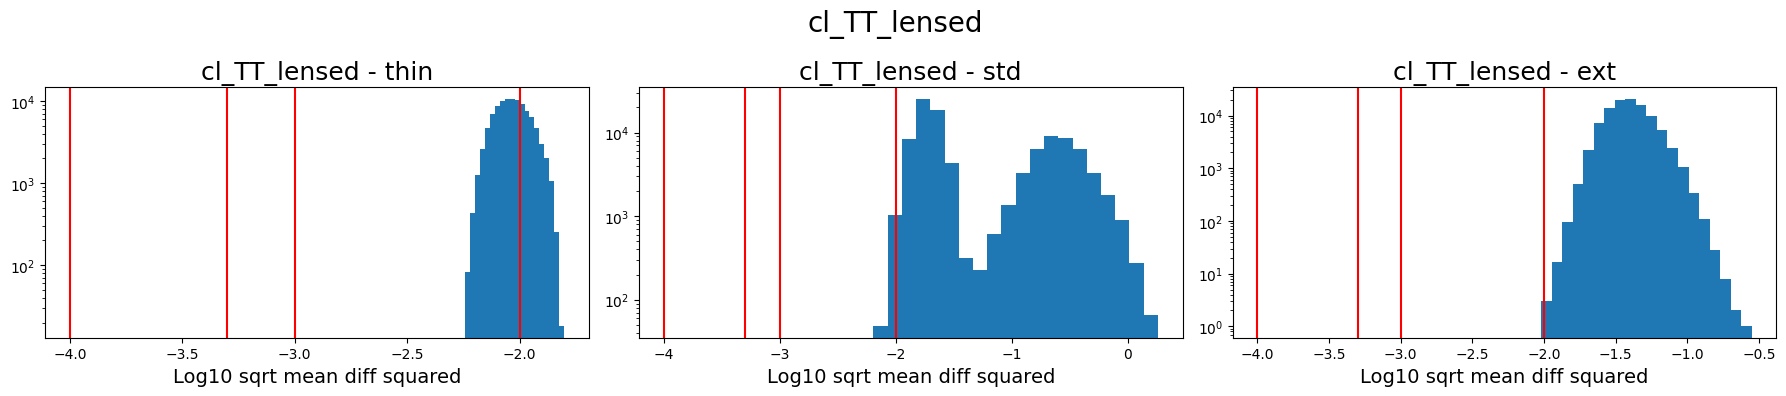

| range   | >0.01%   | >0.05%   | >0.1%    | >1.0%   |   Time emu (s) |   Time total (s) | Epochs (best/tot)   |     Loss |   Val Loss |    LR |
|---------+----------+----------+----------+---------+----------------+------------------+---------------------+----------+------------+-------|
| thin    | 99.998%  | 99.998%  | 99.998%  | 33.704% |        4.6e-06 |          0.0001  | 332/399             | 0.000124 |   0.000123 | 0.001 |
| std     | 100.000% | 100.000% | 100.000% | 99.680% |        3.4e-06 |          0.00024 | 332/399             | 0.000124 |   0.000123 | 0.001 |
| ext     | 100.000% | 100.000% | 100.000% | 99.997% |        3.3e-06 |          0.00044 | 332/399             | 0.000124 |   0.000123 | 0.001 |


In [6]:
emudata, spectrum, diff = show_summary(root)

2026-04-10 09:24:33.697551: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2026-04-10 09:24:38.334188: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 409600000 exceeds 10% of free system memory.
2026-04-10 09:24:39.007039: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 409600000 exceeds 10% of free system memory.
2026-04-10 09:24:39.036724: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 409600000 exceeds 10% of free system memory.
2026-04-10 09:24:39.063249: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 409600000 exceeds 10% of free system memory.
2026-04-10 09:24:39.213499: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 409600000 exceeds 10% of free system memory.


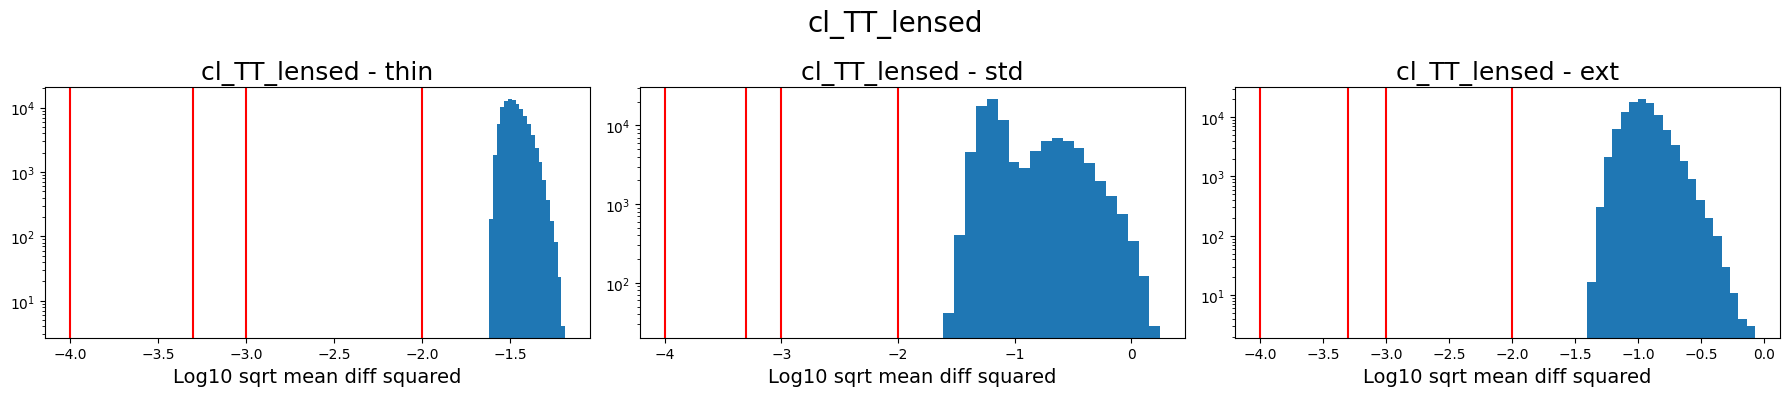

| range   | >0.01%   | >0.05%   | >0.1%    | >1.0%    |   Time emu (s) |   Time total (s) | Epochs (best/tot)   |   Loss |   Val Loss |    LR |
|---------+----------+----------+----------+----------+----------------+------------------+---------------------+--------+------------+-------|
| thin    | 99.998%  | 99.998%  | 99.998%  | 99.998%  |        1.1e-05 |          0.00079 | 46/2046             | 0.0111 |      0.011 | 0.001 |
| std     | 100.000% | 100.000% | 100.000% | 100.000% |        3e-06   |          0.00012 | 46/2046             | 0.0111 |      0.011 | 0.001 |
| ext     | 100.000% | 100.000% | 100.000% | 100.000% |        3.4e-06 |          0.00011 | 46/2046             | 0.0111 |      0.011 | 0.001 |


In [6]:
emudata, spectrum, diff = show_summary(root)

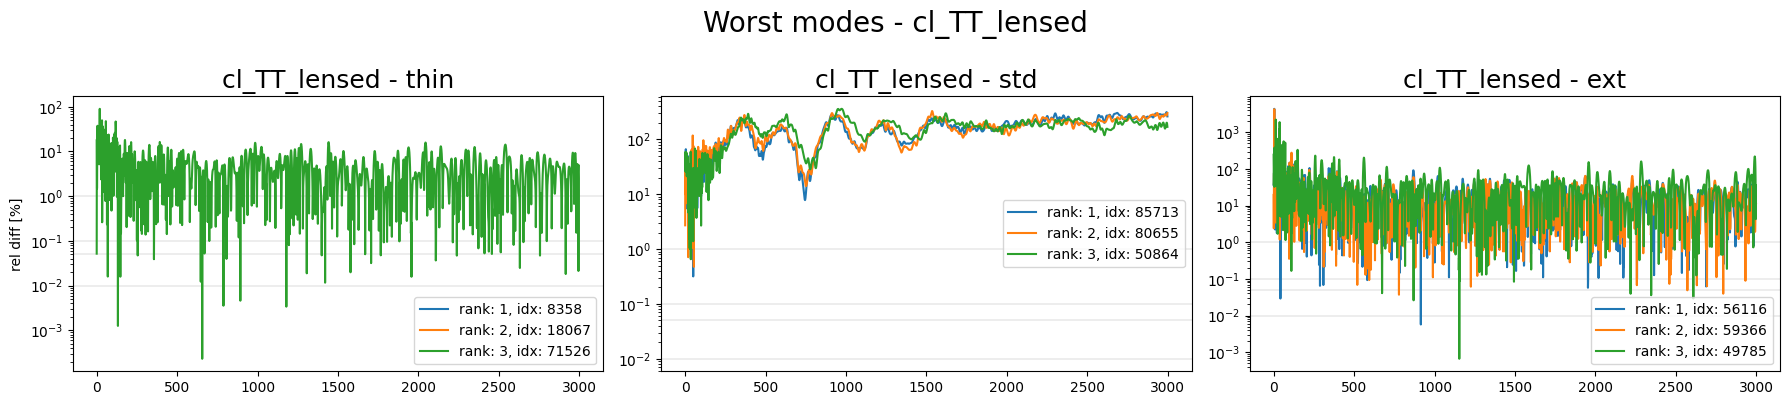

In [7]:
plot_worst_modes(emudata, spectrum, diff, n_modes_kept=3)

# Running check

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

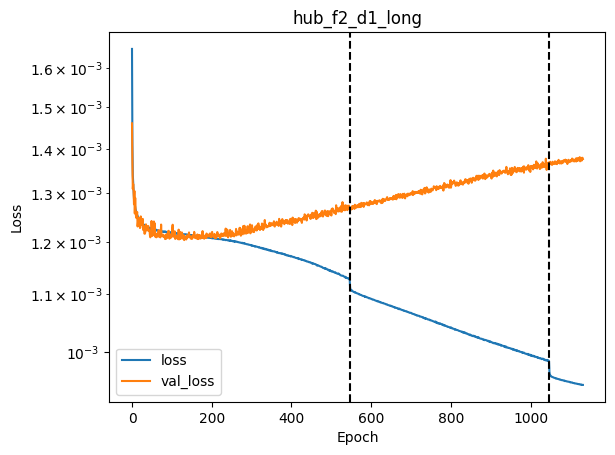

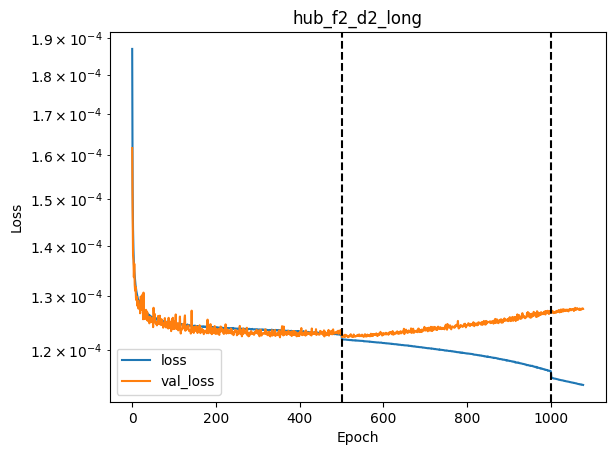

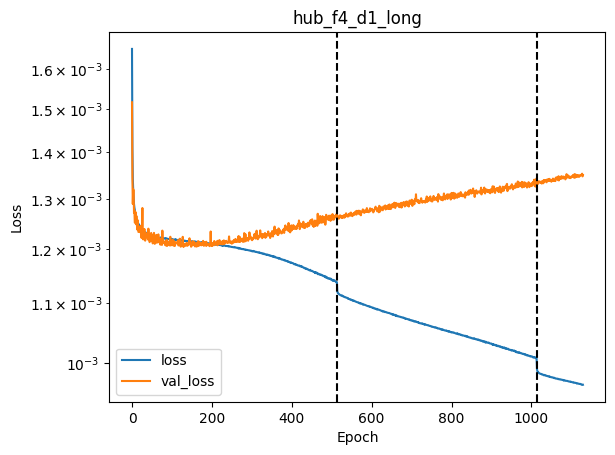

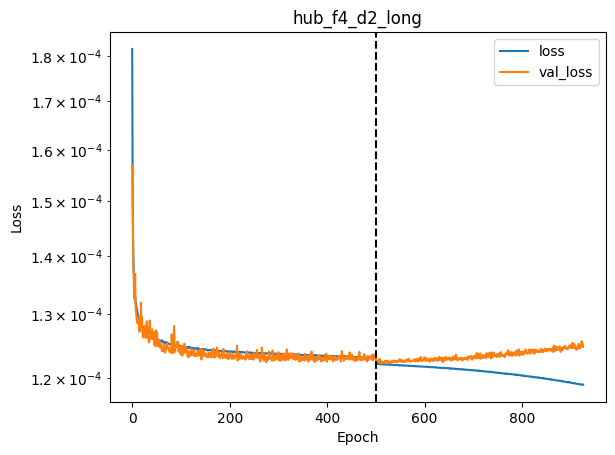

In [2]:
# epoch, learning_rate, loss, val_loss

roots = [
    '/ceph/hpc/data/s25r06-05-users/test/hub_f2_d1_long',
    '/ceph/hpc/data/s25r06-05-users/test/hub_f2_d2_long',
    '/ceph/hpc/data/s25r06-05-users/test/hub_f4_d1_long',
    '/ceph/hpc/data/s25r06-05-users/test/hub_f4_d2_long',
]

for root in roots:
    path = os.path.join(root, 'history_log.csv')
    data = np.genfromtxt(path, delimiter=',', names=True)
    plt.plot(data['epoch'], data['loss'], label='loss')
    plt.plot(data['epoch'], data['val_loss'], label='val_loss')
    # Vertical lines for change in learning rate
    for idx in range(1, len(data['learning_rate'])):
        if data['learning_rate'][idx] != data['learning_rate'][idx-1]:
            plt.axvline(x=data['epoch'][idx], color='k', linestyle='--', label='LR change' if idx == 1 else None)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.yscale('log')
    plt.title(os.path.basename(root))
    plt.legend()
    plt.show()


# Check datasets

## Std

In [ ]:
# Outlier investigation — std dataset

In [6]:
from scipy.spatial import KDTree
import matplotlib.pyplot as plt
import numpy as np
import os
import yaml
from tabulate import tabulate
import emu_like.io as io
from emu_like.ffnn_emu import FFNNEmu

# Pick the emulator to use for the investigation
emu_root = '/ceph/hpc/data/s25r06-05-users/test/hub_f4_d2'

with open(os.path.join(emu_root, 'params.yaml')) as f:
    params = yaml.safe_load(f)

spectrum = params['datasets']['name']

# Load the std dataset
std_path = [p for p in params['datasets']['paths'] if '_std' in p][0]
ds = io.FitsFile(std_path)
x_std = ds.get_data('x_data')
y_std = ds.get_data(spectrum)

print(f"x shape: {x_std.shape}, y shape: {y_std.shape}")
print(f"Spectrum: {spectrum}")

2026-04-10 16:20:15.233812: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-10 16:20:15.888094: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-10 16:20:16.025493: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775830816.283782 1776474 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775830816.288972 1776474 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775830816.492894 1776474 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

x shape: (100000, 8), y shape: (100000, 2999)
Spectrum: cl_TT_lensed


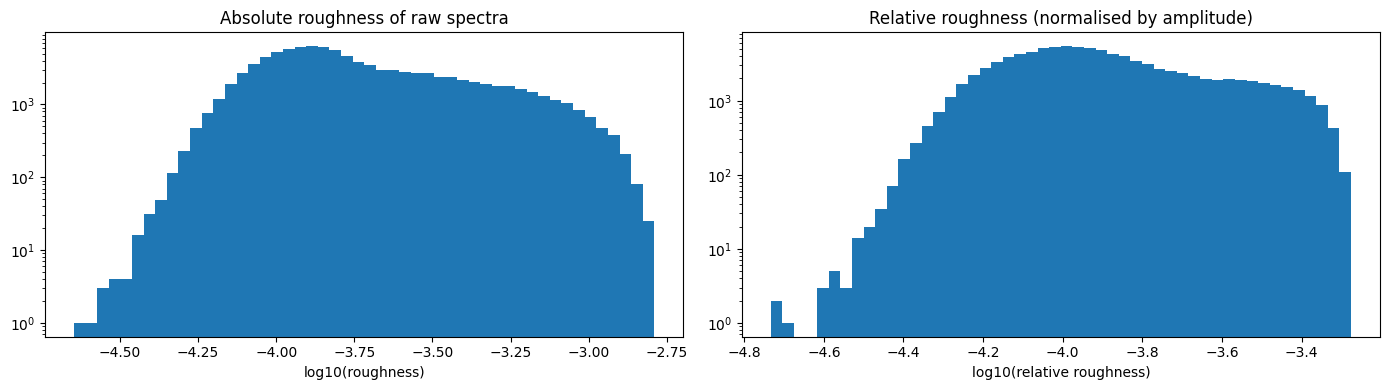

Roughness outliers (top 0.1%): 100 / 100000
Threshold: 4.957988e-04


In [7]:
# Step 1: Check the raw spectra for smoothness
# Compute a "roughness" metric: std of the second derivative (finite differences)

dy = np.diff(y_std, n=2, axis=1)
roughness = np.std(dy, axis=1)

# Also compute relative roughness normalised by the spectrum amplitude
amp = np.max(np.abs(y_std), axis=1)
rel_roughness = roughness / amp

fig, axs = plt.subplots(1, 2, figsize=(14, 4))
axs[0].hist(np.log10(roughness), bins=50, log=True)
axs[0].set_xlabel('log10(roughness)')
axs[0].set_title('Absolute roughness of raw spectra')
axs[1].hist(np.log10(rel_roughness), bins=50, log=True)
axs[1].set_xlabel('log10(relative roughness)')
axs[1].set_title('Relative roughness (normalised by amplitude)')
plt.tight_layout()
plt.show()

# Flag outliers (e.g. top 0.1% roughness)
threshold = np.percentile(rel_roughness, 99.9)
outlier_mask_roughness = rel_roughness > threshold
print(f"Roughness outliers (top 0.1%): {np.sum(outlier_mask_roughness)} / {len(rel_roughness)}")
print(f"Threshold: {threshold:.6e}")

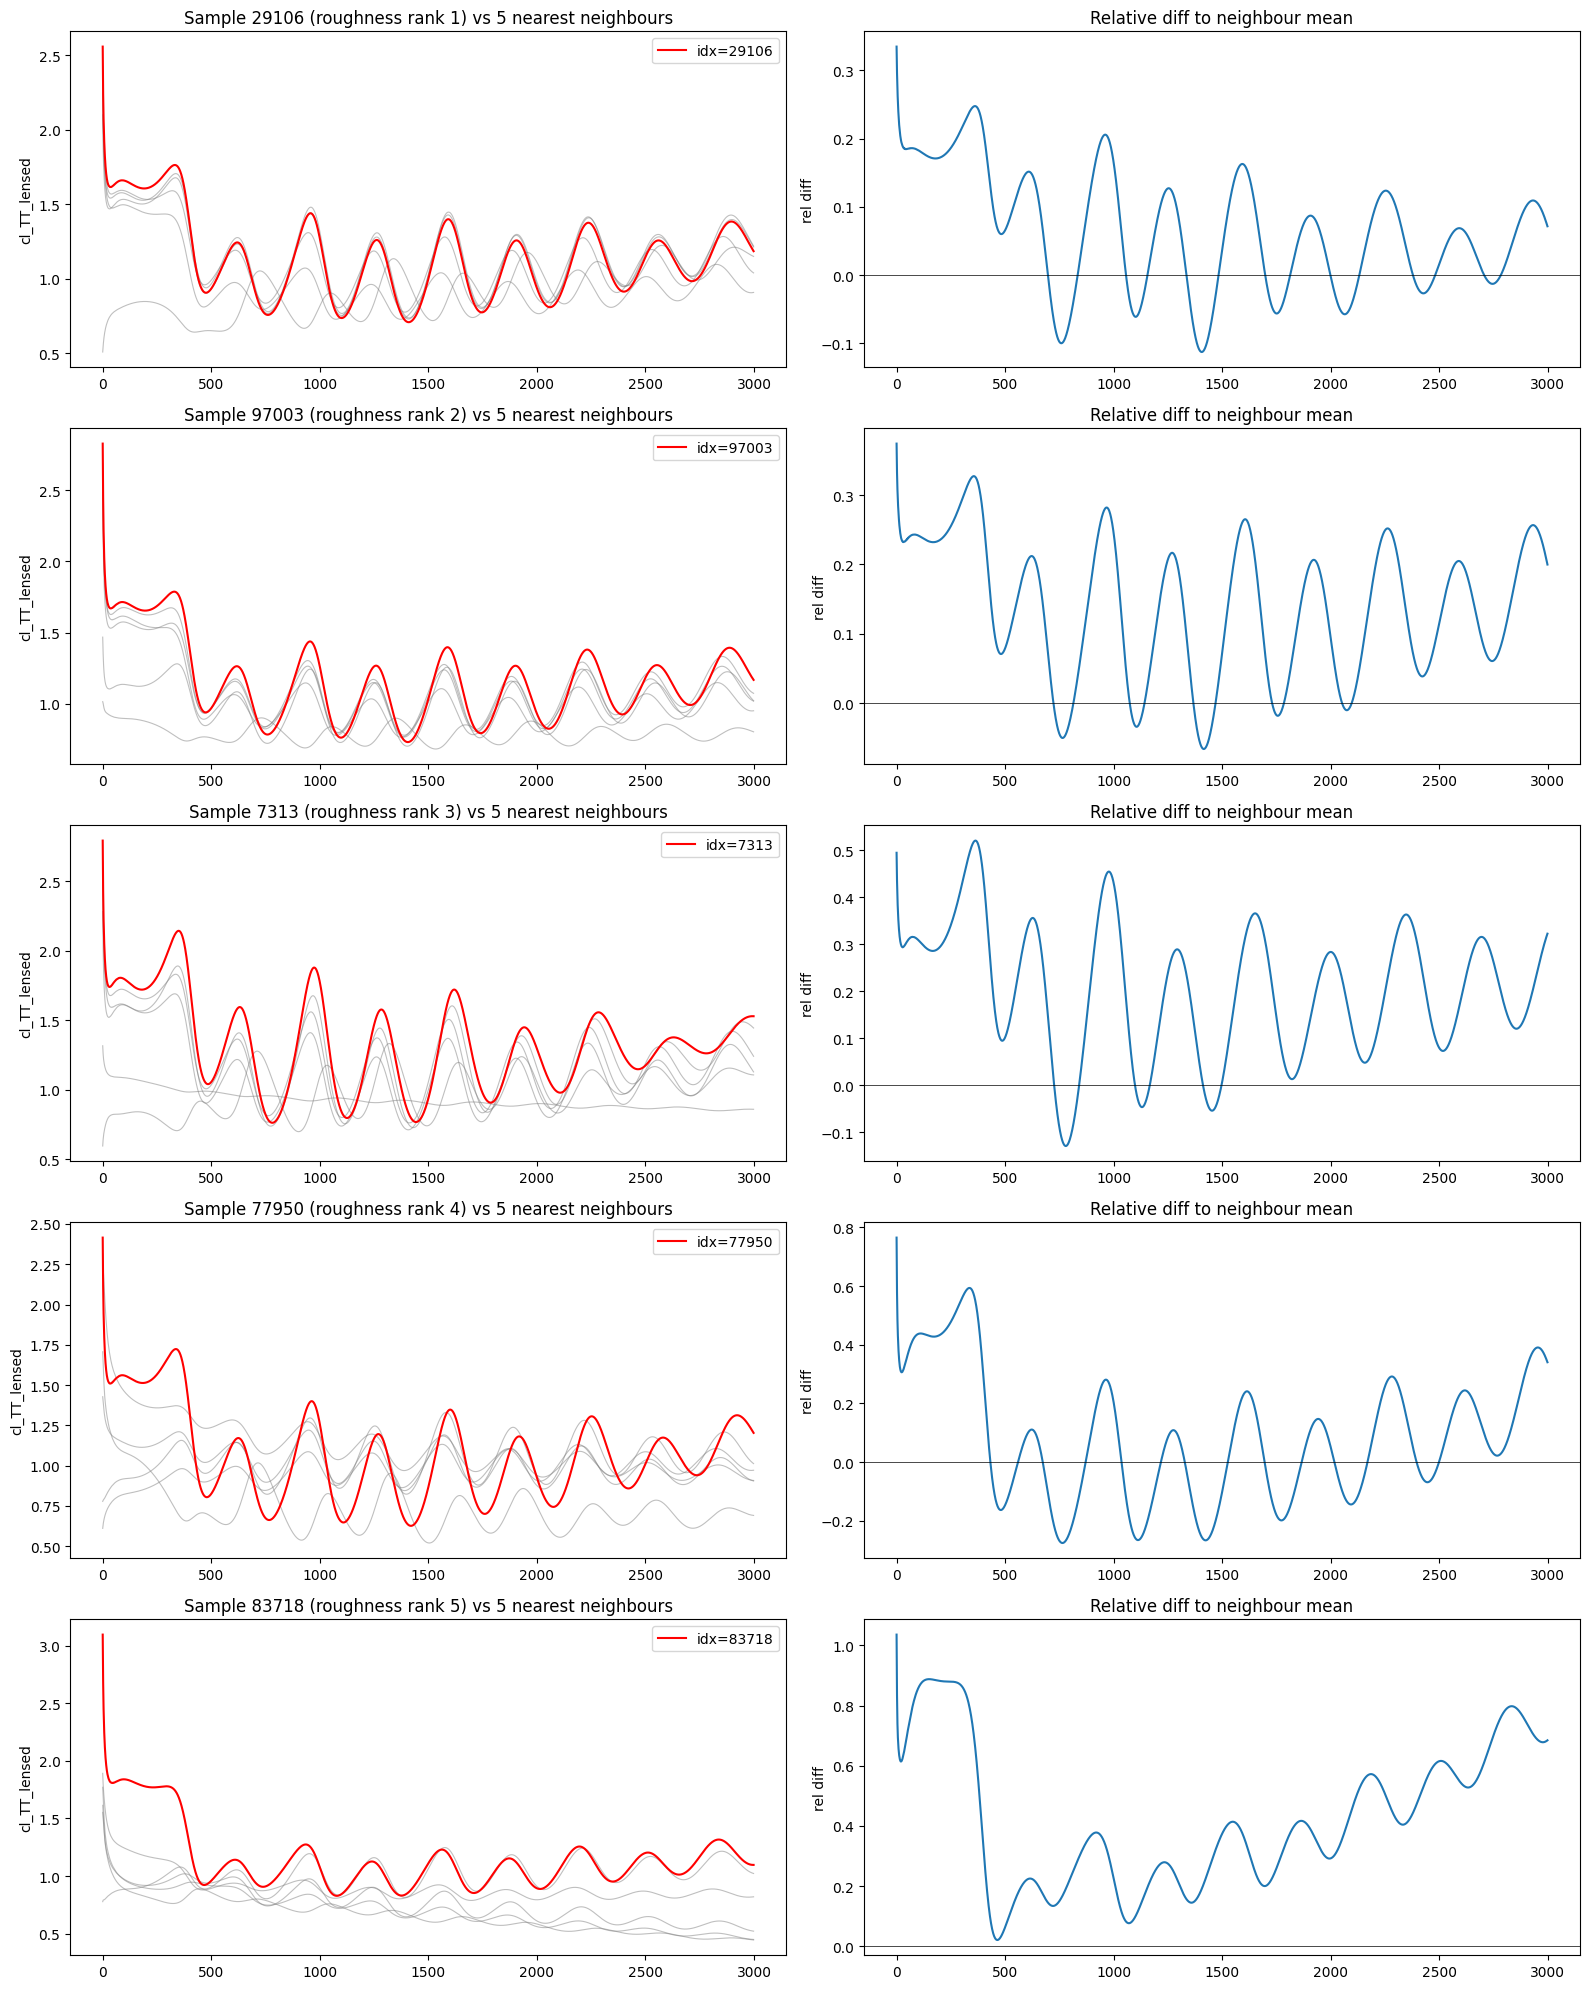

In [8]:
# Step 2: Compare outlier spectra to their nearest neighbours in parameter space

# Normalise x for fair distance computation
x_mean = np.mean(x_std, axis=0)
x_scale = np.std(x_std, axis=0)
x_norm = (x_std - x_mean) / x_scale

tree = KDTree(x_norm)

# Pick the top-N worst samples by relative roughness
n_worst = 5
worst_idxs = np.argsort(rel_roughness)[-n_worst:][::-1]
k_neighbours = 5

fig, axs = plt.subplots(n_worst, 2, figsize=(16, 4*n_worst))

for i, idx in enumerate(worst_idxs):
    # Find nearest neighbours
    dists, nn_idxs = tree.query(x_norm[idx], k=k_neighbours+1)
    nn_idxs = nn_idxs[1:]  # exclude self

    # Plot spectrum vs neighbours
    for nn in nn_idxs:
        axs[i, 0].plot(y_std[nn], color='gray', alpha=0.5, lw=0.8)
    axs[i, 0].plot(y_std[idx], color='red', lw=1.5, label=f'idx={idx}')
    axs[i, 0].set_title(f'Sample {idx} (roughness rank {i+1}) vs {k_neighbours} nearest neighbours')
    axs[i, 0].legend()
    axs[i, 0].set_ylabel(spectrum)

    # Plot relative difference to mean of neighbours
    nn_mean = np.mean(y_std[nn_idxs], axis=0)
    rel_diff_to_nn = y_std[idx] / nn_mean - 1.
    axs[i, 1].plot(rel_diff_to_nn)
    axs[i, 1].set_title(f'Relative diff to neighbour mean')
    axs[i, 1].set_ylabel('rel diff')
    axs[i, 1].axhline(0, c='k', lw=0.5)

plt.tight_layout()
plt.show()

2026-04-10 16:23:53.567882: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Top 100 worst emulator errors: overlap with top 100 roughest = 0


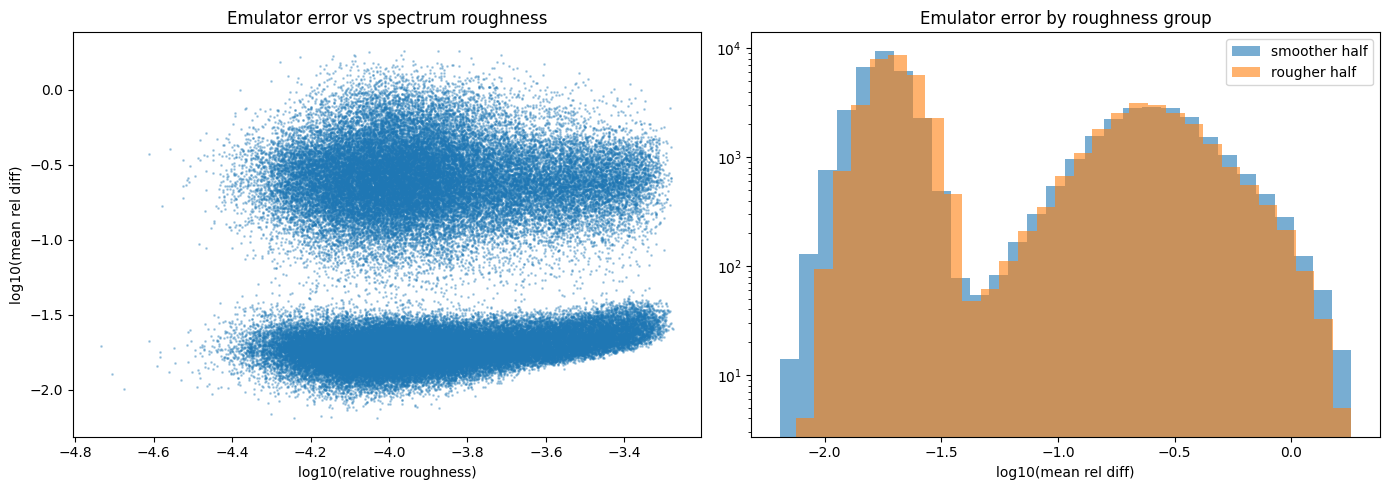

In [11]:
# Step 3: Which samples have large emulator error? Are they the same as the rough ones?

emudata_check = EmuData(emu_root)

ds_std = io.FitsFile(std_path)
x_data = ds_std.get_data('x_data')
y_data = ds_std.get_data(spectrum)

mean_rel = emudata_check.get_mean_rel_diff(
    x_emu=x_data, y_data=y_data,
    want_scaling=False, want_pca=False, time_emu=False)

# Scatter: emulator error vs roughness
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].scatter(np.log10(rel_roughness), np.log10(mean_rel), s=1, alpha=0.3)
axs[0].set_xlabel('log10(relative roughness)')
axs[0].set_ylabel('log10(mean rel diff)')
axs[0].set_title('Emulator error vs spectrum roughness')

# Overlap of worst emulator errors and roughness outliers
n_check = 100
worst_emu = set(np.argsort(mean_rel)[-n_check:])
worst_rough = set(np.argsort(rel_roughness)[-n_check:])
overlap = worst_emu & worst_rough
print(f"Top {n_check} worst emulator errors: overlap with top {n_check} roughest = {len(overlap)}")

# Histogram of emulator error split by roughness
median_roughness = np.median(rel_roughness)
mask_smooth = rel_roughness <= median_roughness
mask_rough = rel_roughness > median_roughness

axs[1].hist(np.log10(mean_rel[mask_smooth]), bins=30, alpha=0.6, label='smoother half', log=True)
axs[1].hist(np.log10(mean_rel[mask_rough]), bins=30, alpha=0.6, label='rougher half', log=True)
axs[1].set_xlabel('log10(mean rel diff)')
axs[1].set_title('Emulator error by roughness group')
axs[1].legend()

plt.tight_layout()
plt.show()

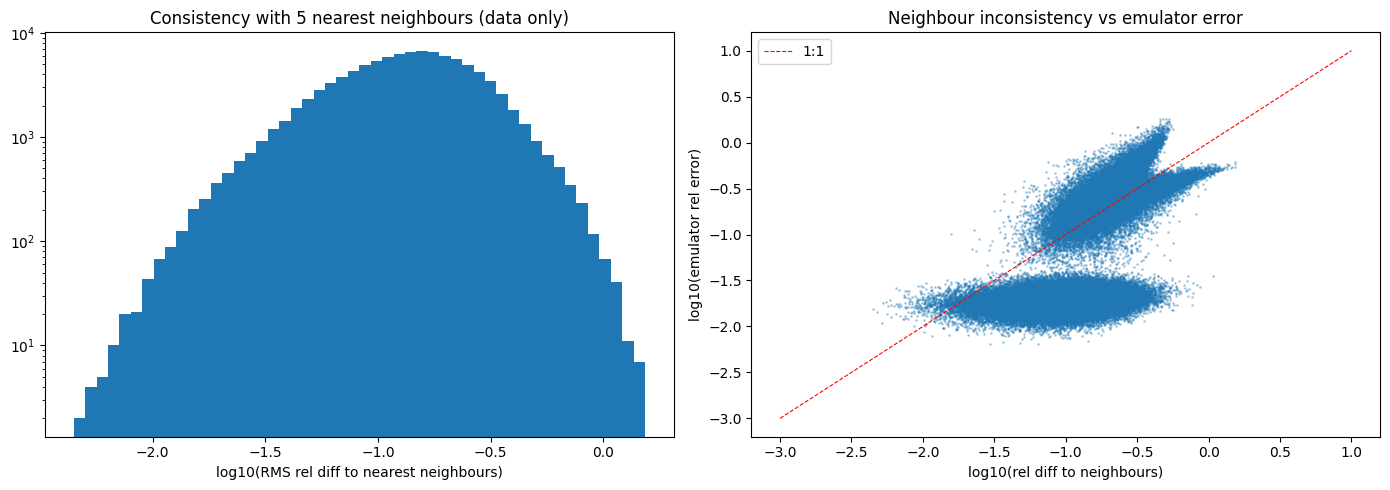

Samples deviating >99th pctile from neighbours: 1000
Threshold: 6.4729e-01
Worst 10 indices: [65891 83134 56175 74185 87557 69973 77691 52126 49848 84975]


In [12]:
# Step 4: Check nearest-neighbour consistency (data-only, no emulator)
# For each sample, compare it to the mean of its k nearest neighbours.
# Large deviations suggest the sample itself is an outlier, not just hard to emulate.

k_nn = 5
dists, nn_all = tree.query(x_norm, k=k_nn+1)
nn_all = nn_all[:, 1:]  # exclude self

# Mean relative deviation from neighbours
nn_mean_spectra = np.mean(y_std[nn_all], axis=1)  # (N, n_ell)
rel_dev_nn = np.sqrt(np.mean((y_std / nn_mean_spectra - 1.)**2, axis=1))

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].hist(np.log10(rel_dev_nn), bins=50, log=True)
axs[0].set_xlabel('log10(RMS rel diff to nearest neighbours)')
axs[0].set_title(f'Consistency with {k_nn} nearest neighbours (data only)')

# Scatter: nn deviation vs emulator error
axs[1].scatter(np.log10(rel_dev_nn), np.log10(mean_rel), s=1, alpha=0.3)
axs[1].set_xlabel('log10(rel diff to neighbours)')
axs[1].set_ylabel('log10(emulator rel error)')
axs[1].set_title('Neighbour inconsistency vs emulator error')
axs[1].plot([-3, 1], [-3, 1], 'r--', lw=0.8, label='1:1')
axs[1].legend()

plt.tight_layout()
plt.show()

# Identify suspicious samples
threshold_nn = np.percentile(rel_dev_nn, 99)
suspicious = np.where(rel_dev_nn > threshold_nn)[0]
print(f"Samples deviating >99th pctile from neighbours: {len(suspicious)}")
print(f"Threshold: {threshold_nn:.4e}")
print(f"Worst 10 indices: {np.argsort(rel_dev_nn)[-10:][::-1]}")

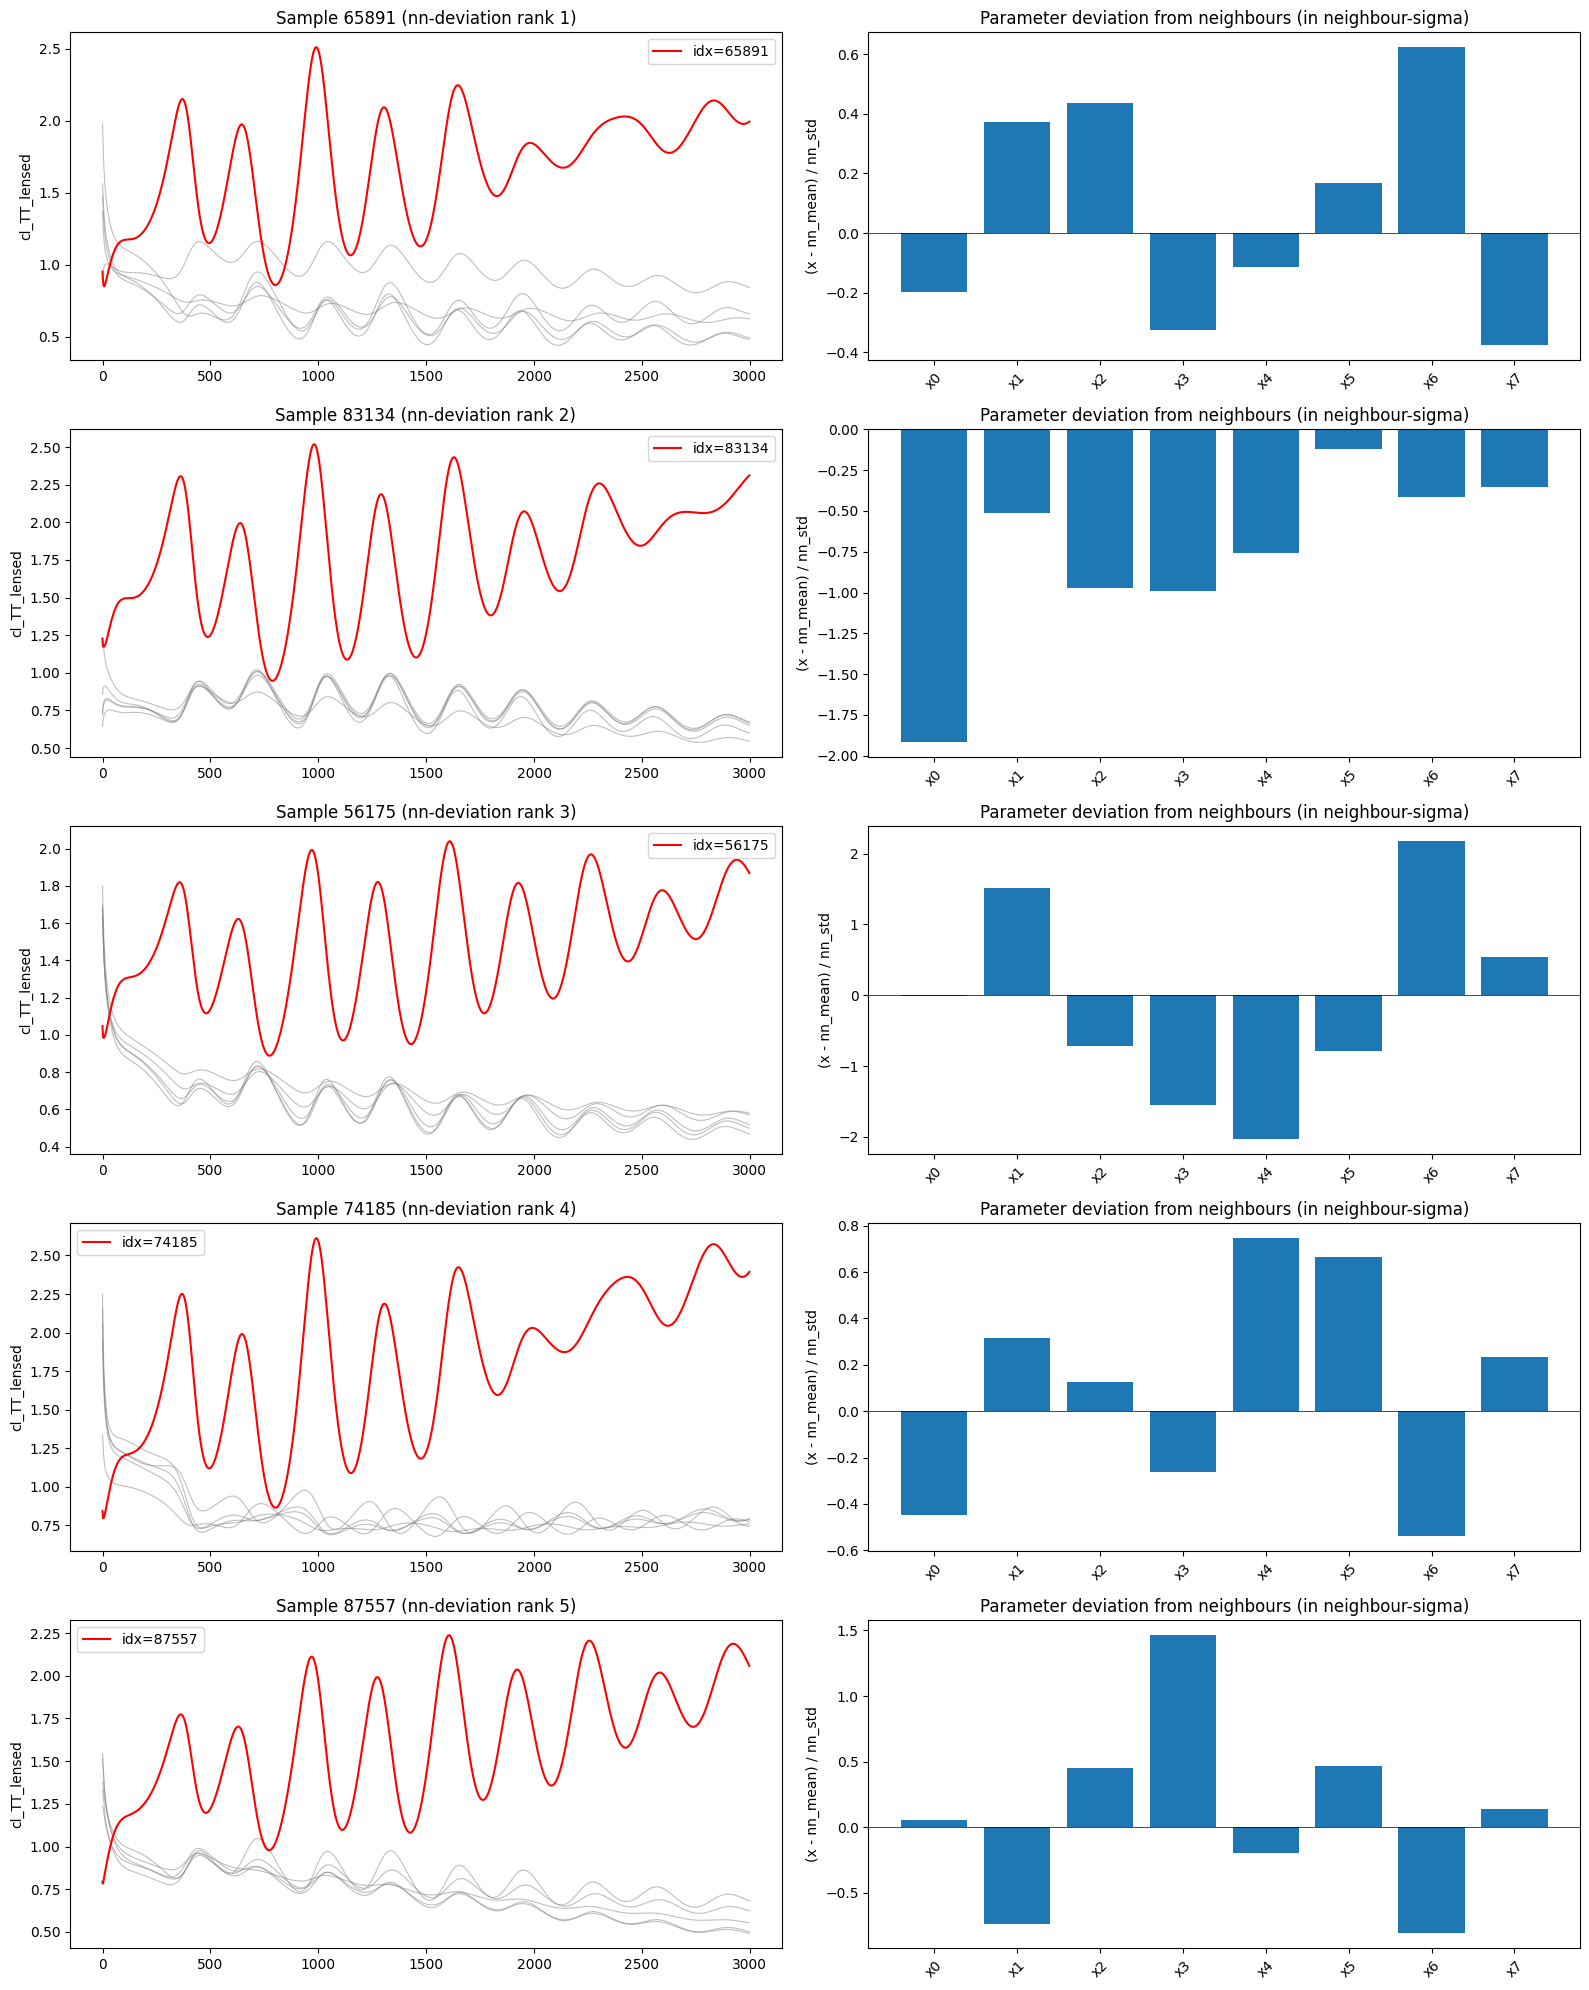

In [13]:
# Step 5: Plot the most suspicious samples (largest deviation from neighbours)
n_show = 5
worst_nn_idxs = np.argsort(rel_dev_nn)[-n_show:][::-1]

fig, axs = plt.subplots(n_show, 2, figsize=(16, 4*n_show))

for i, idx in enumerate(worst_nn_idxs):
    nn_idxs = nn_all[idx]

    # Spectra comparison
    for nn in nn_idxs:
        axs[i, 0].plot(y_std[nn], color='gray', alpha=0.5, lw=0.8)
    axs[i, 0].plot(y_std[idx], color='red', lw=1.5, label=f'idx={idx}')
    axs[i, 0].set_title(f'Sample {idx} (nn-deviation rank {i+1})')
    axs[i, 0].legend()
    axs[i, 0].set_ylabel(spectrum)

    # Parameters comparison
    x_params = x_std[idx]
    x_nn_params = x_std[nn_idxs]
    x_labels = [f'x{j}' for j in range(x_std.shape[1])]
    
    # Show parameter values as bar chart (normalised)
    x_nn_mean = np.mean(x_nn_params, axis=0)
    x_nn_std = np.std(x_nn_params, axis=0)
    x_nn_std[x_nn_std == 0] = 1.  # avoid division by zero
    deviation = (x_params - x_nn_mean) / x_nn_std
    axs[i, 1].bar(range(len(deviation)), deviation)
    axs[i, 1].set_xticks(range(len(x_labels)))
    axs[i, 1].set_xticklabels(x_labels, rotation=45)
    axs[i, 1].set_title(f'Parameter deviation from neighbours (in neighbour-sigma)')
    axs[i, 1].set_ylabel('(x - nn_mean) / nn_std')
    axs[i, 1].axhline(0, c='k', lw=0.5)

plt.tight_layout()
plt.show()

In [14]:
# Get parameter names from the emulator's data.fits
x_names = emudata_check.emu.x_names

# Top 10 worst points by emulator error
n_top = 10
worst_emu_idxs = np.argsort(mean_rel)[-n_top:][::-1]

print(f"Parameter names: {x_names}\n")
print(f"{'Rank':<5} {'Index':<8} {'Mean rel err':<14} {'NN dev':<14} {'Roughness':<14} | {('  '.join([f'{n:>12s}' for n in x_names]))}")
print("-" * (55 + 14*len(x_names)))
for rank, idx in enumerate(worst_emu_idxs):
    vals = '  '.join([f'{v:12.5e}' for v in x_std[idx]])
    print(f"{rank+1:<5} {idx:<8} {mean_rel[idx]:<14.4e} {rel_dev_nn[idx]:<14.4e} {rel_roughness[idx]:<14.4e} | {vals}")

Parameter names: ['h', 'Omega_m', 'Omega_b', 'ln_A_s_1e10', 'n_s', 'tau_reio', 'N_ur', 'm_ncdm']

Rank  Index    Mean rel err   NN dev         Roughness      |            h       Omega_m       Omega_b   ln_A_s_1e10           n_s      tau_reio          N_ur        m_ncdm
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
1     85713    1.8141e+00     4.6033e-01     1.3365e-04     |  6.51111e-01   2.12044e-01   5.02993e-02   3.16155e+00   1.09698e+00   2.86571e-02   5.13199e-01   3.37039e-02
2     80655    1.8050e+00     4.7637e-01     1.0886e-04     |  7.00153e-01   2.19020e-01   5.86786e-02   3.19794e+00   9.97741e-01   6.48857e-02   6.74948e-01   9.82879e-02
3     50864    1.8032e+00     5.2413e-01     1.5095e-04     |  6.01953e-01   2.08246e-01   4.28379e-02   3.14982e+00   1.06521e+00   3.60987e-02   8.05426e-01   1.19854e-01
4     61571    1.7884e+00     5.0659e-01  

## Thin

In [15]:
# Load thin dataset
thin_path = [p for p in params['datasets']['paths'] if '_thin' in p][0]
ds_thin = io.FitsFile(thin_path)
x_thin = ds_thin.get_data('x_data')
y_thin = ds_thin.get_data(spectrum)

print(f"x shape: {x_thin.shape}, y shape: {y_thin.shape}")
print(f"Spectrum: {spectrum}")
print(f"Dataset: {thin_path}")

x shape: (100000, 8), y shape: (100000, 2999)
Spectrum: cl_TT_lensed
Dataset: /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_thin.fits


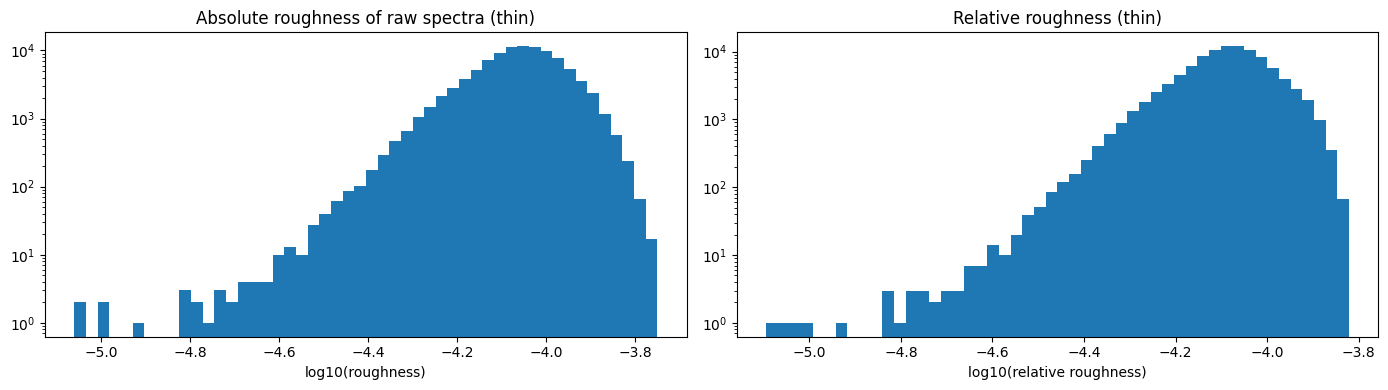

Roughness outliers (top 0.1%): 0 / 100000
Threshold: nan


In [16]:
# Step 1: Roughness
dy_thin = np.diff(y_thin, n=2, axis=1)
roughness_thin = np.std(dy_thin, axis=1)
amp_thin = np.max(np.abs(y_thin), axis=1)
rel_roughness_thin = roughness_thin / amp_thin

fig, axs = plt.subplots(1, 2, figsize=(14, 4))
axs[0].hist(np.log10(roughness_thin), bins=50, log=True)
axs[0].set_xlabel('log10(roughness)')
axs[0].set_title('Absolute roughness of raw spectra (thin)')
axs[1].hist(np.log10(rel_roughness_thin), bins=50, log=True)
axs[1].set_xlabel('log10(relative roughness)')
axs[1].set_title('Relative roughness (thin)')
plt.tight_layout()
plt.show()

threshold_thin = np.percentile(rel_roughness_thin, 99.9)
outlier_mask_thin = rel_roughness_thin > threshold_thin
print(f"Roughness outliers (top 0.1%): {np.sum(outlier_mask_thin)} / {len(rel_roughness_thin)}")
print(f"Threshold: {threshold_thin:.6e}")

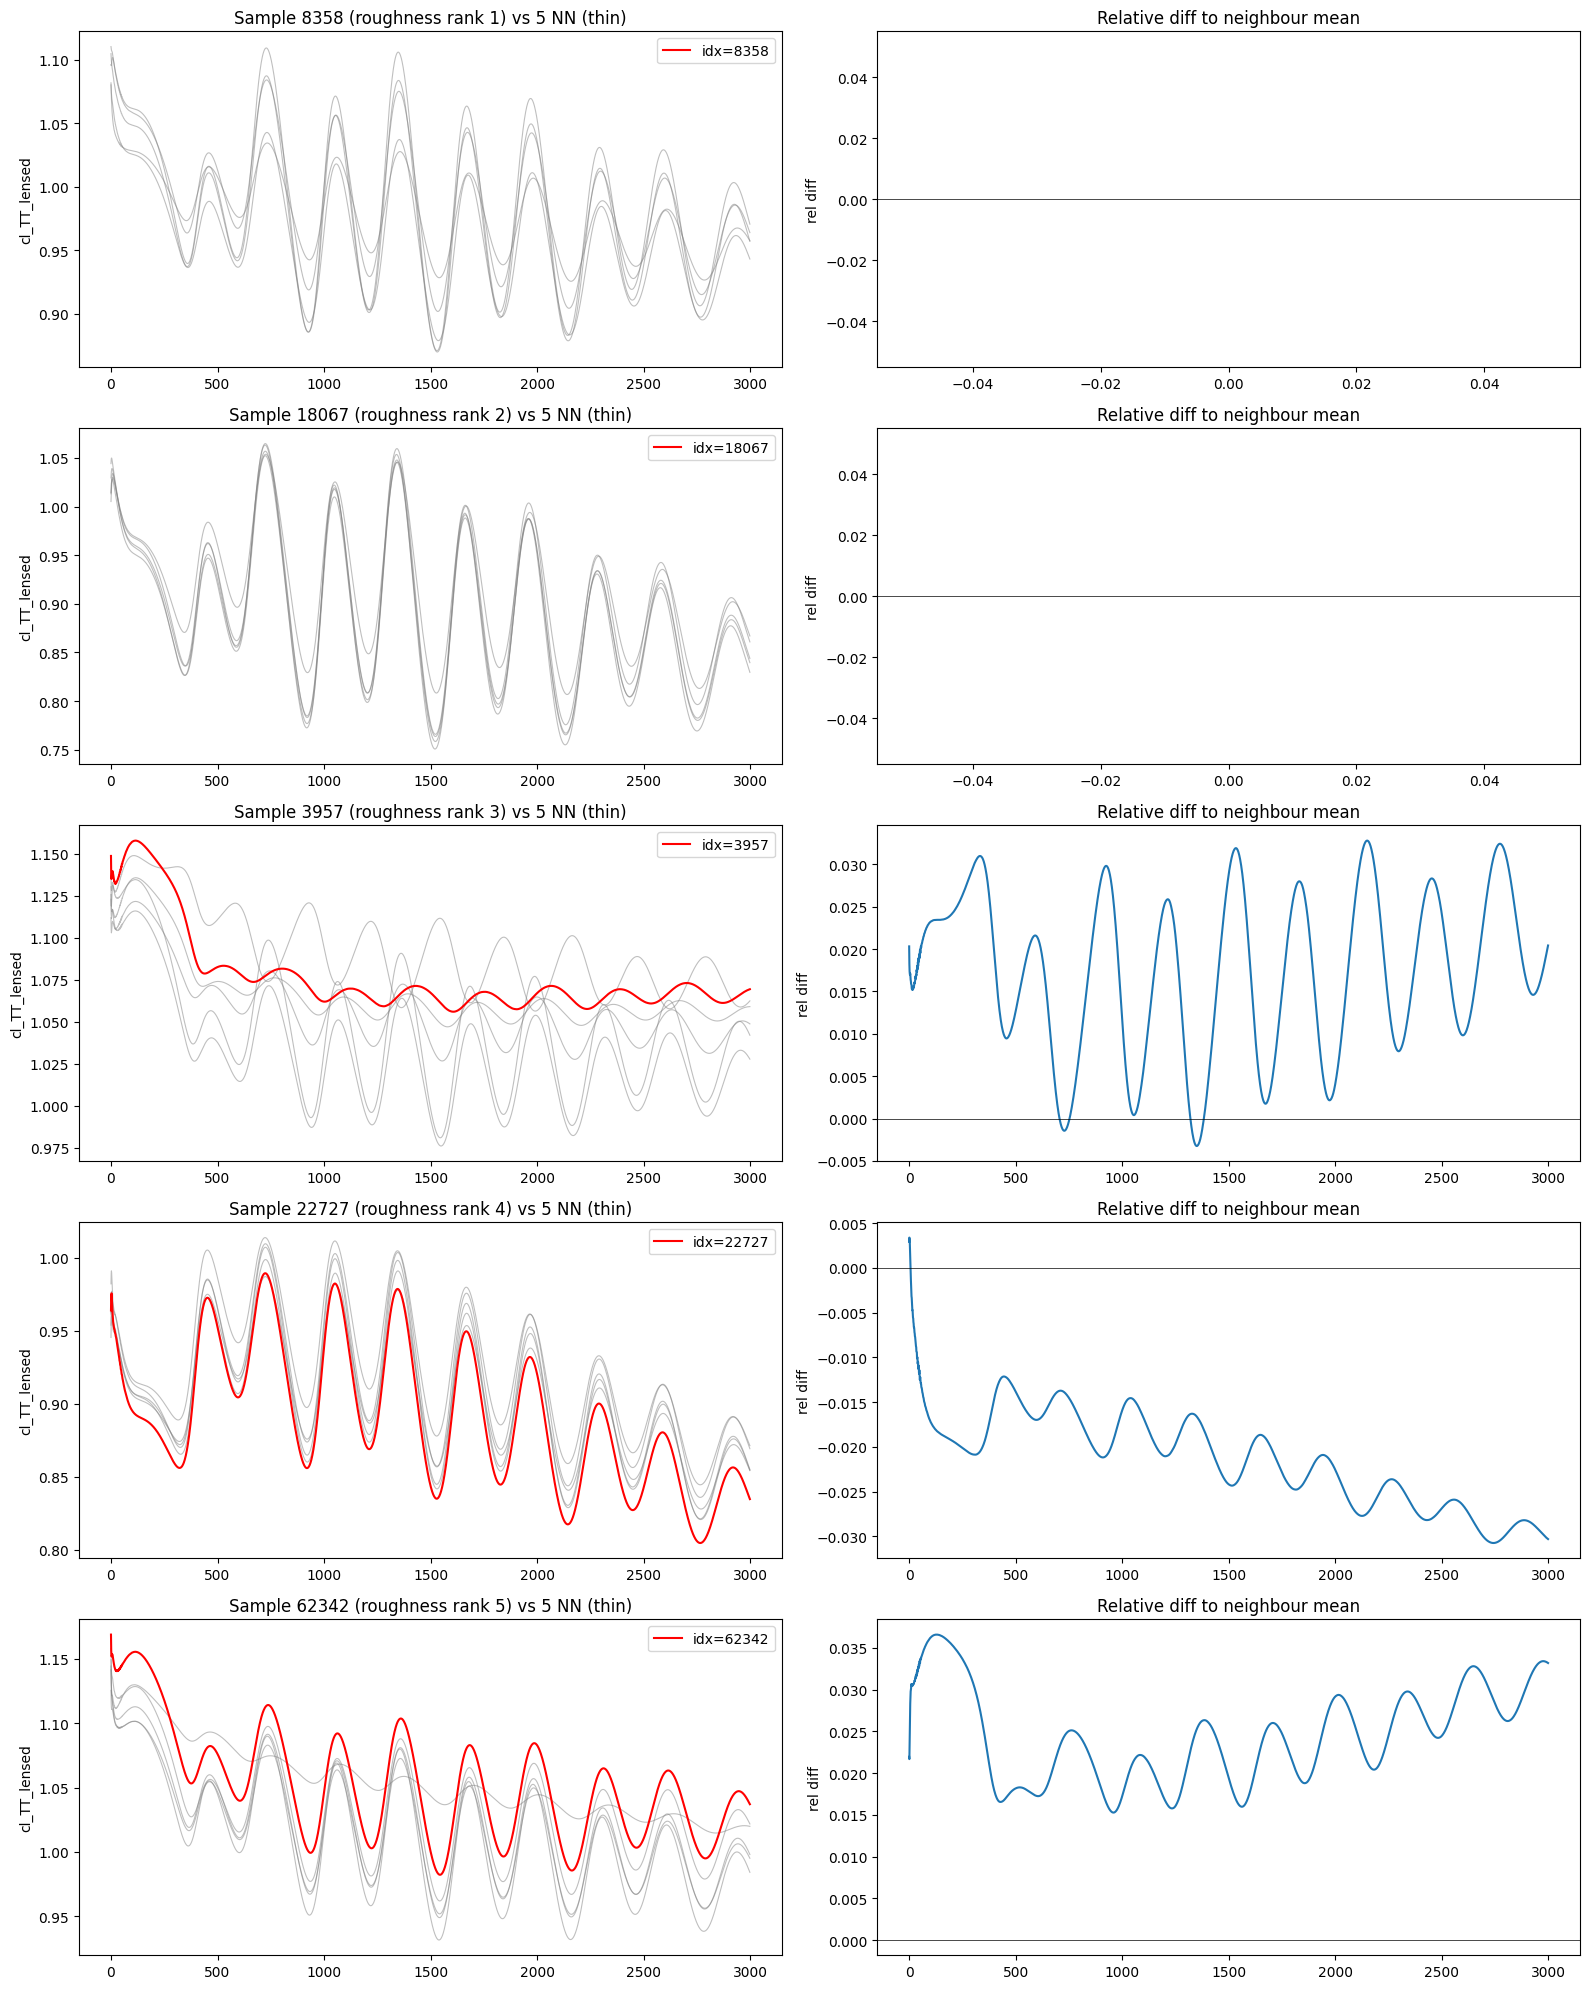

In [17]:
# Step 2: Roughest spectra vs neighbours
x_mean_thin = np.mean(x_thin, axis=0)
x_scale_thin = np.std(x_thin, axis=0)
x_norm_thin = (x_thin - x_mean_thin) / x_scale_thin
tree_thin = KDTree(x_norm_thin)

n_worst = 5
worst_idxs_thin = np.argsort(rel_roughness_thin)[-n_worst:][::-1]
k_neighbours = 5

fig, axs = plt.subplots(n_worst, 2, figsize=(16, 4*n_worst))
for i, idx in enumerate(worst_idxs_thin):
    dists_t, nn_idxs_t = tree_thin.query(x_norm_thin[idx], k=k_neighbours+1)
    nn_idxs_t = nn_idxs_t[1:]
    for nn in nn_idxs_t:
        axs[i, 0].plot(y_thin[nn], color='gray', alpha=0.5, lw=0.8)
    axs[i, 0].plot(y_thin[idx], color='red', lw=1.5, label=f'idx={idx}')
    axs[i, 0].set_title(f'Sample {idx} (roughness rank {i+1}) vs {k_neighbours} NN (thin)')
    axs[i, 0].legend()
    axs[i, 0].set_ylabel(spectrum)
    nn_mean_t = np.mean(y_thin[nn_idxs_t], axis=0)
    rel_diff_t = y_thin[idx] / nn_mean_t - 1.
    axs[i, 1].plot(rel_diff_t)
    axs[i, 1].set_title('Relative diff to neighbour mean')
    axs[i, 1].set_ylabel('rel diff')
    axs[i, 1].axhline(0, c='k', lw=0.5)
plt.tight_layout()
plt.show()

Top 100 worst emulator errors: overlap with top 100 roughest = 2


/tmp/ipykernel_1776474/3034392707.py:27: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.tight_layout()


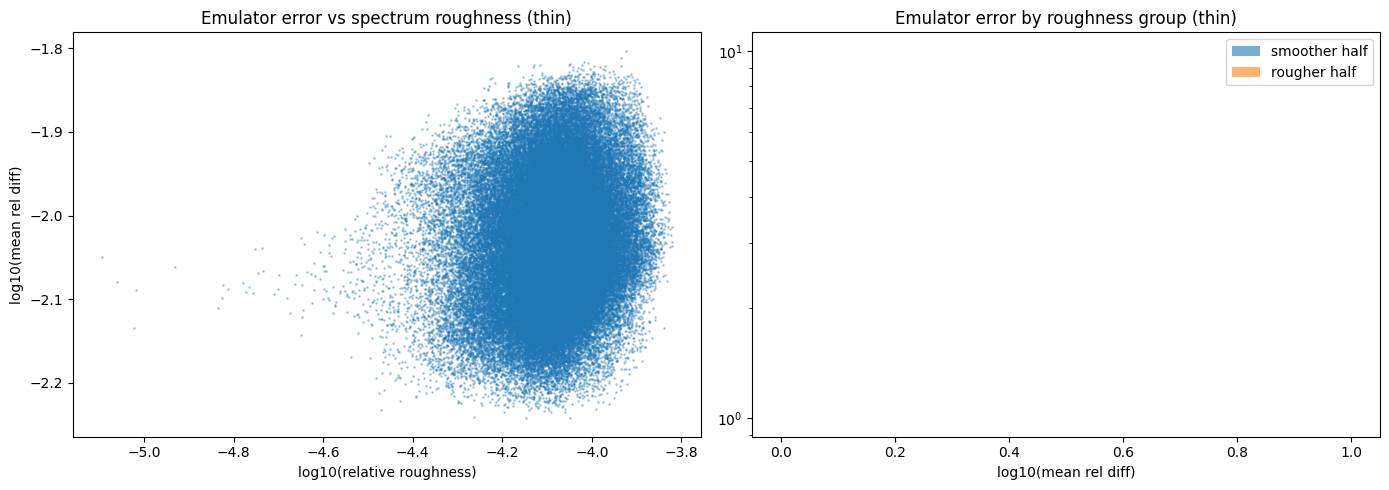

In [18]:
# Step 3: Emulator error vs roughness
emudata_thin = EmuData(emu_root)
mean_rel_thin = emudata_thin.get_mean_rel_diff(
    x_emu=x_thin, y_data=y_thin,
    want_scaling=False, want_pca=False, time_emu=False)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].scatter(np.log10(rel_roughness_thin), np.log10(mean_rel_thin), s=1, alpha=0.3)
axs[0].set_xlabel('log10(relative roughness)')
axs[0].set_ylabel('log10(mean rel diff)')
axs[0].set_title('Emulator error vs spectrum roughness (thin)')

n_check = 100
worst_emu_thin = set(np.argsort(mean_rel_thin)[-n_check:])
worst_rough_thin = set(np.argsort(rel_roughness_thin)[-n_check:])
overlap_thin = worst_emu_thin & worst_rough_thin
print(f"Top {n_check} worst emulator errors: overlap with top {n_check} roughest = {len(overlap_thin)}")

median_roughness_thin = np.median(rel_roughness_thin)
mask_smooth_thin = rel_roughness_thin <= median_roughness_thin
mask_rough_thin = rel_roughness_thin > median_roughness_thin
axs[1].hist(np.log10(mean_rel_thin[mask_smooth_thin]), bins=30, alpha=0.6, label='smoother half', log=True)
axs[1].hist(np.log10(mean_rel_thin[mask_rough_thin]), bins=30, alpha=0.6, label='rougher half', log=True)
axs[1].set_xlabel('log10(mean rel diff)')
axs[1].set_title('Emulator error by roughness group (thin)')
axs[1].legend()
plt.tight_layout()
plt.show()

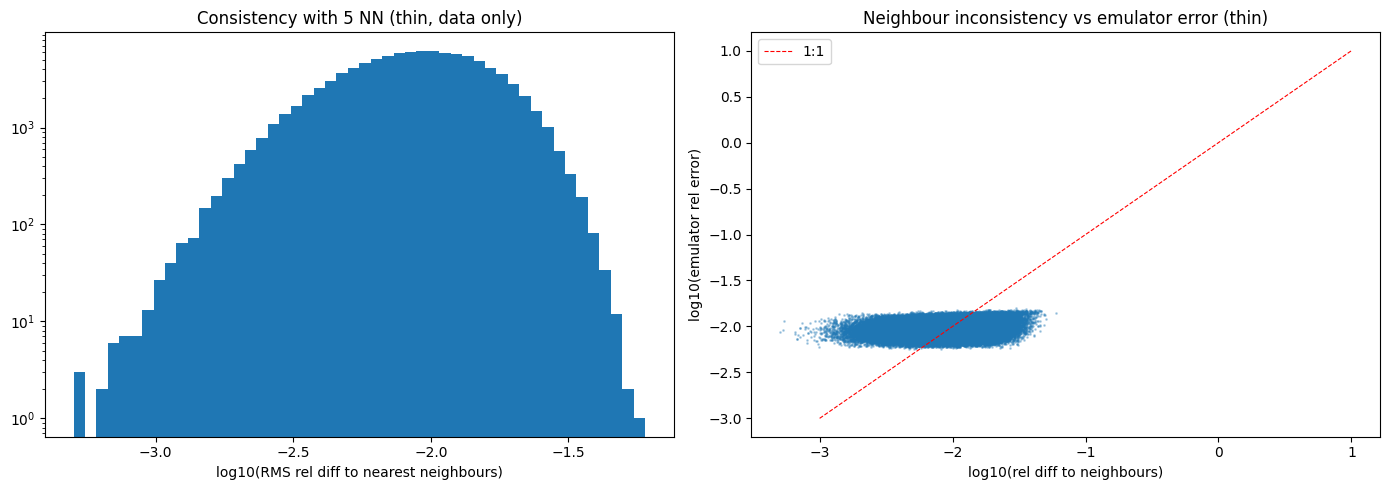

Samples deviating >99th pctile from neighbours: 0
Threshold: nan
Worst 10 indices: [51199 49626 41692   939 18067 39026 56459 78145  8358 33990]


In [19]:
# Step 4: Nearest-neighbour consistency (data-only)
k_nn = 5
dists_thin, nn_all_thin = tree_thin.query(x_norm_thin, k=k_nn+1)
nn_all_thin = nn_all_thin[:, 1:]
nn_mean_spectra_thin = np.mean(y_thin[nn_all_thin], axis=1)
rel_dev_nn_thin = np.sqrt(np.mean((y_thin / nn_mean_spectra_thin - 1.)**2, axis=1))

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].hist(np.log10(rel_dev_nn_thin), bins=50, log=True)
axs[0].set_xlabel('log10(RMS rel diff to nearest neighbours)')
axs[0].set_title(f'Consistency with {k_nn} NN (thin, data only)')

axs[1].scatter(np.log10(rel_dev_nn_thin), np.log10(mean_rel_thin), s=1, alpha=0.3)
axs[1].set_xlabel('log10(rel diff to neighbours)')
axs[1].set_ylabel('log10(emulator rel error)')
axs[1].set_title('Neighbour inconsistency vs emulator error (thin)')
axs[1].plot([-3, 1], [-3, 1], 'r--', lw=0.8, label='1:1')
axs[1].legend()
plt.tight_layout()
plt.show()

threshold_nn_thin = np.percentile(rel_dev_nn_thin, 99)
suspicious_thin = np.where(rel_dev_nn_thin > threshold_nn_thin)[0]
print(f"Samples deviating >99th pctile from neighbours: {len(suspicious_thin)}")
print(f"Threshold: {threshold_nn_thin:.4e}")
print(f"Worst 10 indices: {np.argsort(rel_dev_nn_thin)[-10:][::-1]}")

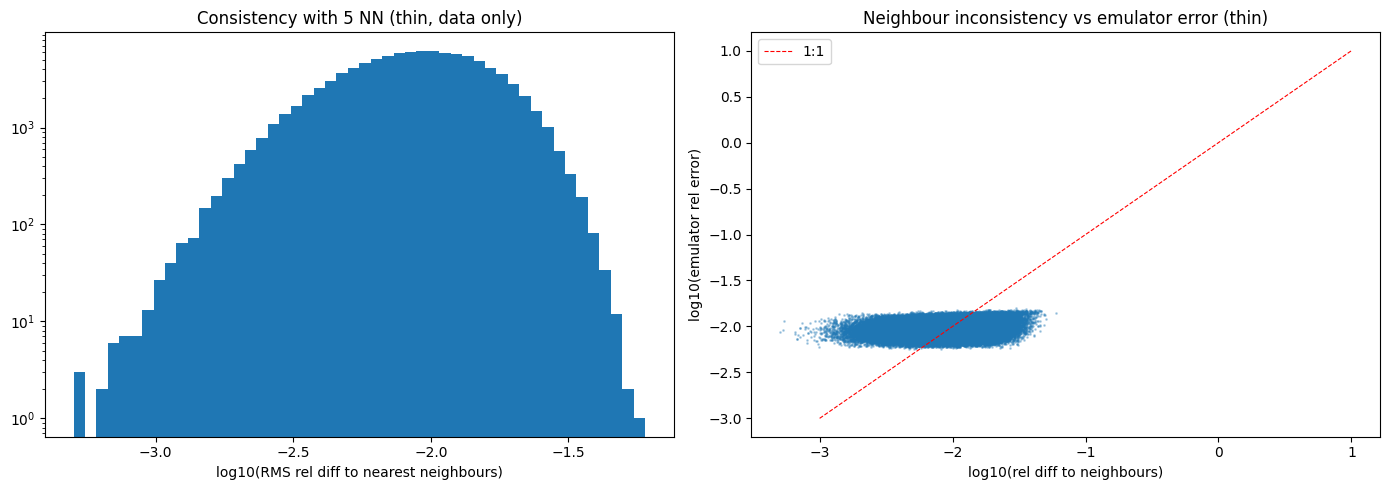

Samples deviating >99th pctile from neighbours: 0
Threshold: nan
Worst 10 indices: [51199 49626 41692   939 18067 39026 56459 78145  8358 33990]


In [20]:
# Step 4: Nearest-neighbour consistency (data-only)
k_nn = 5
dists_thin, nn_all_thin = tree_thin.query(x_norm_thin, k=k_nn+1)
nn_all_thin = nn_all_thin[:, 1:]
nn_mean_spectra_thin = np.mean(y_thin[nn_all_thin], axis=1)
rel_dev_nn_thin = np.sqrt(np.mean((y_thin / nn_mean_spectra_thin - 1.)**2, axis=1))

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].hist(np.log10(rel_dev_nn_thin), bins=50, log=True)
axs[0].set_xlabel('log10(RMS rel diff to nearest neighbours)')
axs[0].set_title(f'Consistency with {k_nn} NN (thin, data only)')

axs[1].scatter(np.log10(rel_dev_nn_thin), np.log10(mean_rel_thin), s=1, alpha=0.3)
axs[1].set_xlabel('log10(rel diff to neighbours)')
axs[1].set_ylabel('log10(emulator rel error)')
axs[1].set_title('Neighbour inconsistency vs emulator error (thin)')
axs[1].plot([-3, 1], [-3, 1], 'r--', lw=0.8, label='1:1')
axs[1].legend()
plt.tight_layout()
plt.show()

threshold_nn_thin = np.percentile(rel_dev_nn_thin, 99)
suspicious_thin = np.where(rel_dev_nn_thin > threshold_nn_thin)[0]
print(f"Samples deviating >99th pctile from neighbours: {len(suspicious_thin)}")
print(f"Threshold: {threshold_nn_thin:.4e}")
print(f"Worst 10 indices: {np.argsort(rel_dev_nn_thin)[-10:][::-1]}")

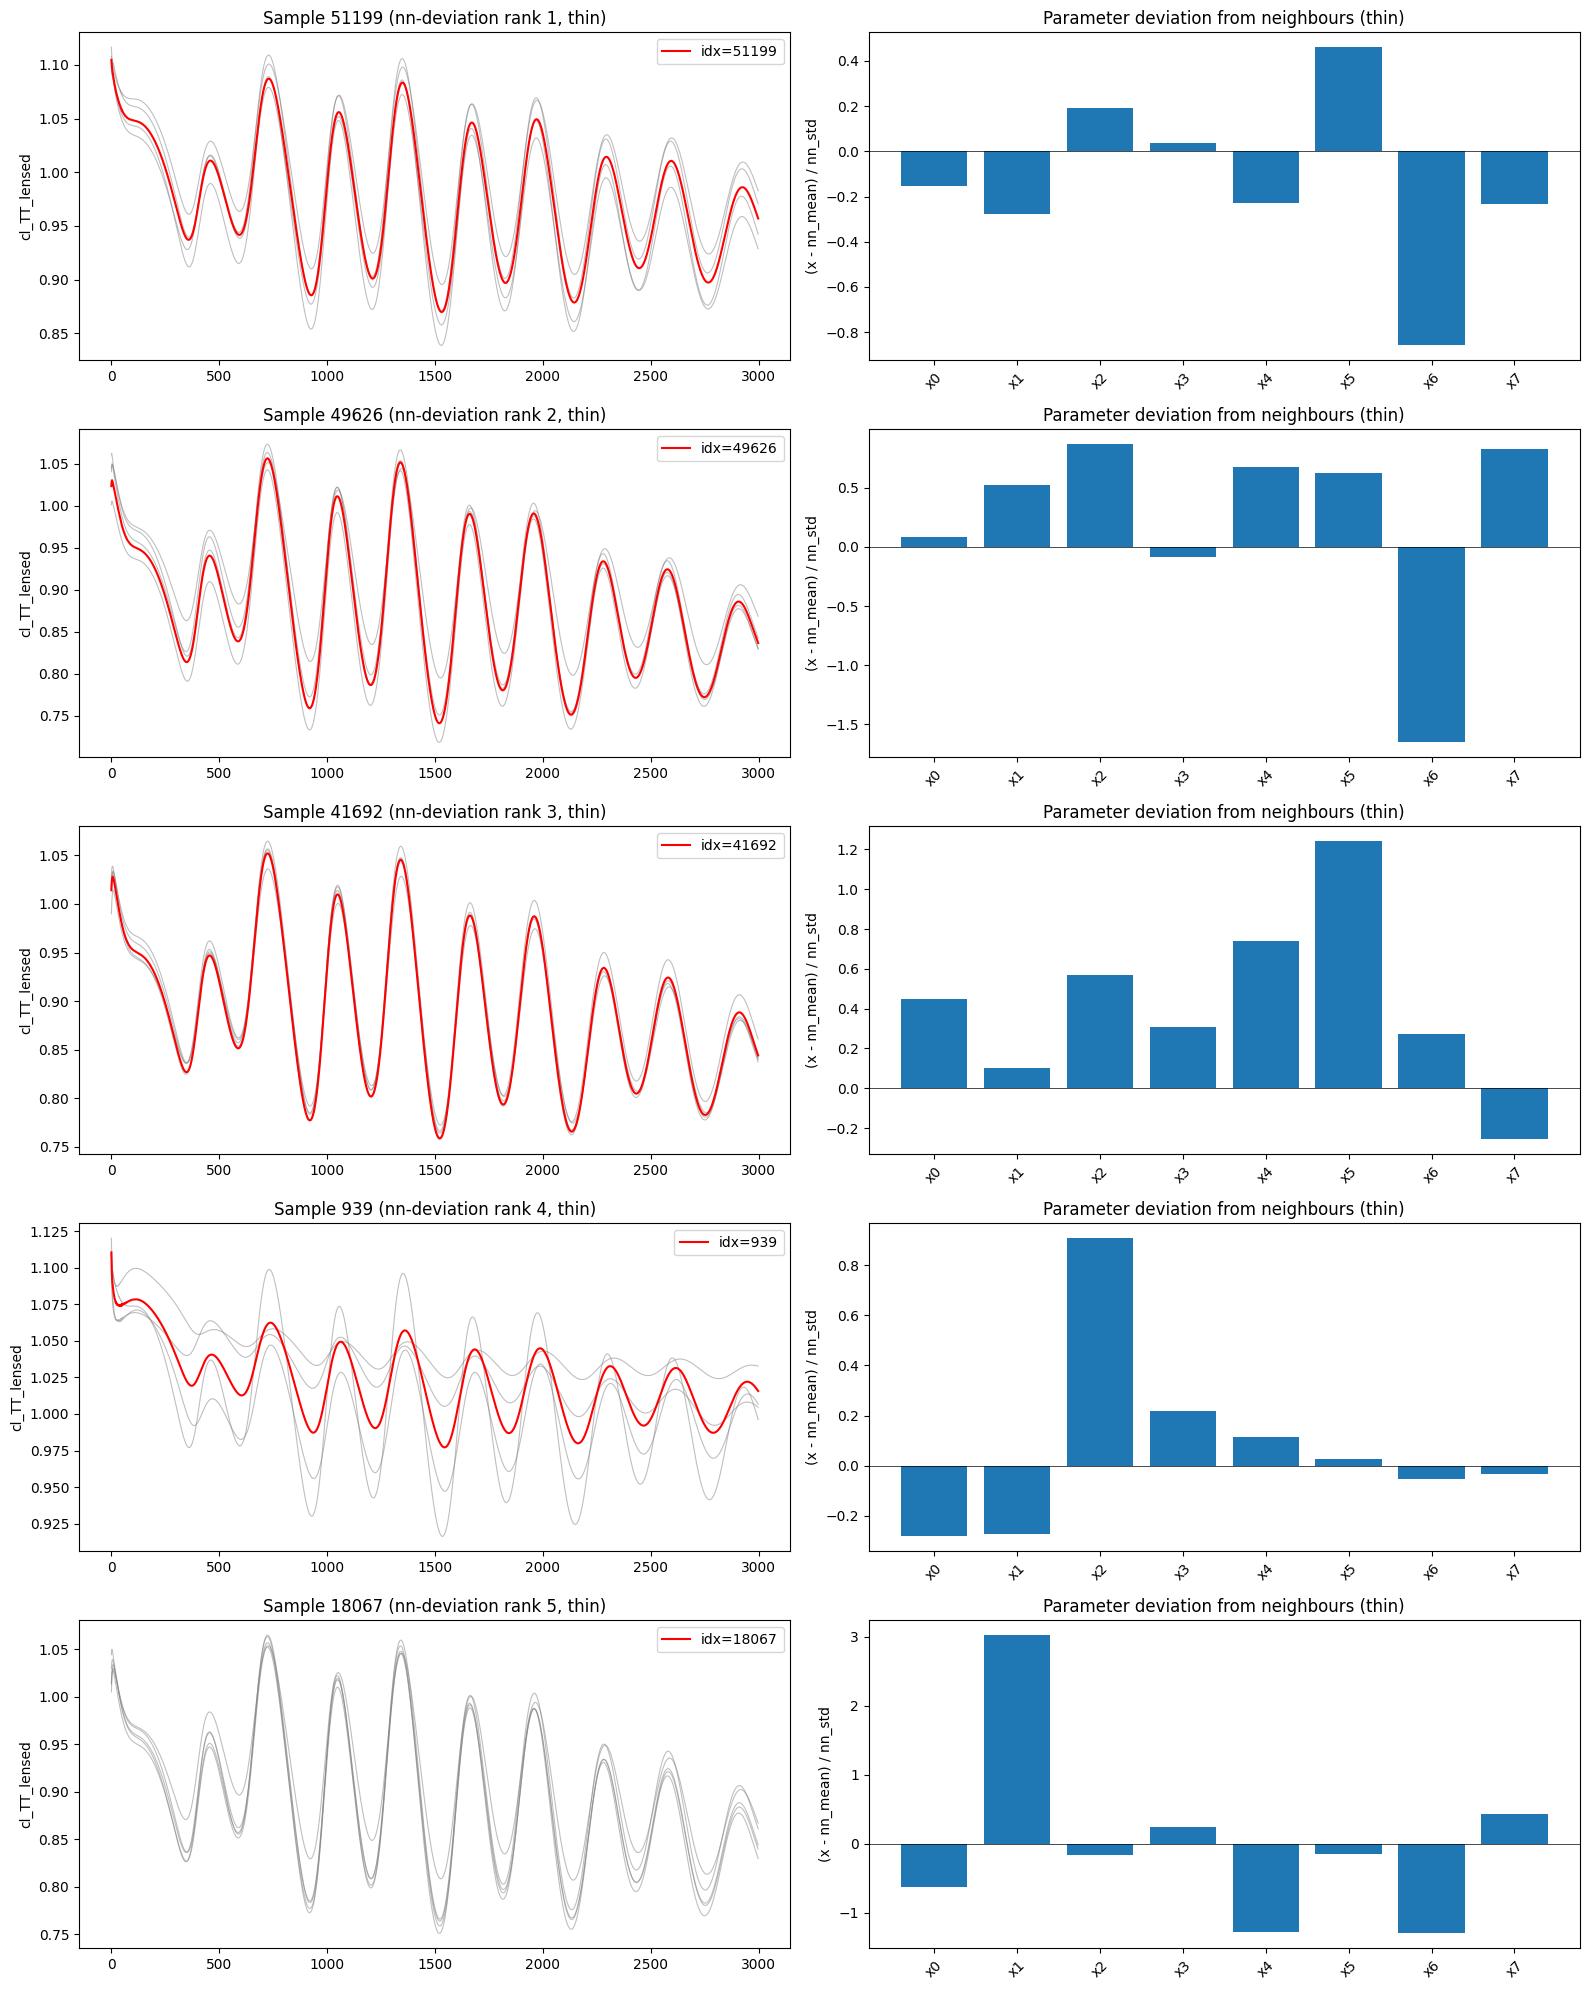

In [21]:
# Step 5: Most suspicious samples
n_show = 5
worst_nn_idxs_thin = np.argsort(rel_dev_nn_thin)[-n_show:][::-1]
fig, axs = plt.subplots(n_show, 2, figsize=(16, 4*n_show))
for i, idx in enumerate(worst_nn_idxs_thin):
    nn_idxs_t = nn_all_thin[idx]
    for nn in nn_idxs_t:
        axs[i, 0].plot(y_thin[nn], color='gray', alpha=0.5, lw=0.8)
    axs[i, 0].plot(y_thin[idx], color='red', lw=1.5, label=f'idx={idx}')
    axs[i, 0].set_title(f'Sample {idx} (nn-deviation rank {i+1}, thin)')
    axs[i, 0].legend()
    axs[i, 0].set_ylabel(spectrum)
    x_params_t = x_thin[idx]
    x_nn_params_t = x_thin[nn_idxs_t]
    x_labels = [f'x{j}' for j in range(x_thin.shape[1])]
    x_nn_mean_t = np.mean(x_nn_params_t, axis=0)
    x_nn_std_t = np.std(x_nn_params_t, axis=0)
    x_nn_std_t[x_nn_std_t == 0] = 1.
    deviation_t = (x_params_t - x_nn_mean_t) / x_nn_std_t
    axs[i, 1].bar(range(len(deviation_t)), deviation_t)
    axs[i, 1].set_xticks(range(len(x_labels)))
    axs[i, 1].set_xticklabels(x_labels, rotation=45)
    axs[i, 1].set_title('Parameter deviation from neighbours (thin)')
    axs[i, 1].set_ylabel('(x - nn_mean) / nn_std')
    axs[i, 1].axhline(0, c='k', lw=0.5)
plt.tight_layout()
plt.show()

In [22]:
# Step 6: Worst points table (thin)
x_names = emudata_thin.emu.x_names
n_top = 10
worst_emu_idxs_thin = np.argsort(mean_rel_thin)[-n_top:][::-1]

print(f"Parameter names: {x_names}\n")
print(f"{'Rank':<5} {'Index':<8} {'Mean rel err':<14} {'NN dev':<14} {'Roughness':<14} | {('  '.join([f'{n:>12s}' for n in x_names]))}")
print("-" * (55 + 14*len(x_names)))
for rank, idx in enumerate(worst_emu_idxs_thin):
    vals = '  '.join([f'{v:12.5e}' for v in x_thin[idx]])
    print(f"{rank+1:<5} {idx:<8} {mean_rel_thin[idx]:<14.4e} {rel_dev_nn_thin[idx]:<14.4e} {rel_roughness_thin[idx]:<14.4e} | {vals}")

Parameter names: ['h', 'Omega_m', 'Omega_b', 'ln_A_s_1e10', 'n_s', 'tau_reio', 'N_ur', 'm_ncdm']

Rank  Index    Mean rel err   NN dev         Roughness      |            h       Omega_m       Omega_b   ln_A_s_1e10           n_s      tau_reio          N_ur        m_ncdm
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
1     8358     nan            nan            nan            |  7.08376e-01   3.12694e-01   4.69087e-02   3.07446e+00   9.55873e-01   5.01462e-02   9.97508e-02   2.78597e-02
2     18067    nan            nan            nan            |  7.00066e-01   3.46542e-01   4.65049e-02   3.04139e+00   9.50836e-01   5.14471e-02   2.75436e-02   3.54269e-02
3     92766    1.5745e-02     2.9912e-02     1.1894e-04     |  7.26268e-01   3.49192e-01   4.40313e-02   2.99669e+00   9.61688e-01   7.38646e-02   1.39509e-02   4.71607e-02
4     66191    1.5433e-02     3.5972e-02  

## Ext

In [23]:
# Load ext dataset
ext_path = [p for p in params['datasets']['paths'] if '_ext' in p][0]
ds_ext = io.FitsFile(ext_path)
x_ext = ds_ext.get_data('x_data')
y_ext = ds_ext.get_data(spectrum)

print(f"x shape: {x_ext.shape}, y shape: {y_ext.shape}")
print(f"Spectrum: {spectrum}")
print(f"Dataset: {ext_path}")

x shape: (100000, 8), y shape: (100000, 2999)
Spectrum: cl_TT_lensed
Dataset: /ceph/hpc/data/s25r06-05-users/lcdm_nu/sample/cl_100_ext.fits


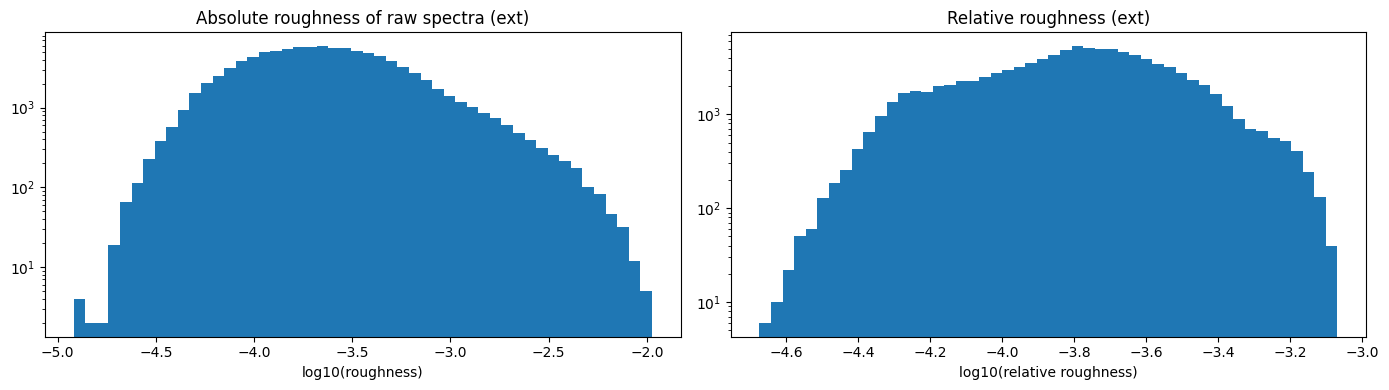

Roughness outliers (top 0.1%): 100 / 100000
Threshold: 7.579045e-04


In [24]:
# Step 1: Roughness
dy_ext = np.diff(y_ext, n=2, axis=1)
roughness_ext = np.std(dy_ext, axis=1)
amp_ext = np.max(np.abs(y_ext), axis=1)
rel_roughness_ext = roughness_ext / amp_ext

fig, axs = plt.subplots(1, 2, figsize=(14, 4))
axs[0].hist(np.log10(roughness_ext), bins=50, log=True)
axs[0].set_xlabel('log10(roughness)')
axs[0].set_title('Absolute roughness of raw spectra (ext)')
axs[1].hist(np.log10(rel_roughness_ext), bins=50, log=True)
axs[1].set_xlabel('log10(relative roughness)')
axs[1].set_title('Relative roughness (ext)')
plt.tight_layout()
plt.show()

threshold_ext = np.percentile(rel_roughness_ext, 99.9)
outlier_mask_ext = rel_roughness_ext > threshold_ext
print(f"Roughness outliers (top 0.1%): {np.sum(outlier_mask_ext)} / {len(rel_roughness_ext)}")
print(f"Threshold: {threshold_ext:.6e}")

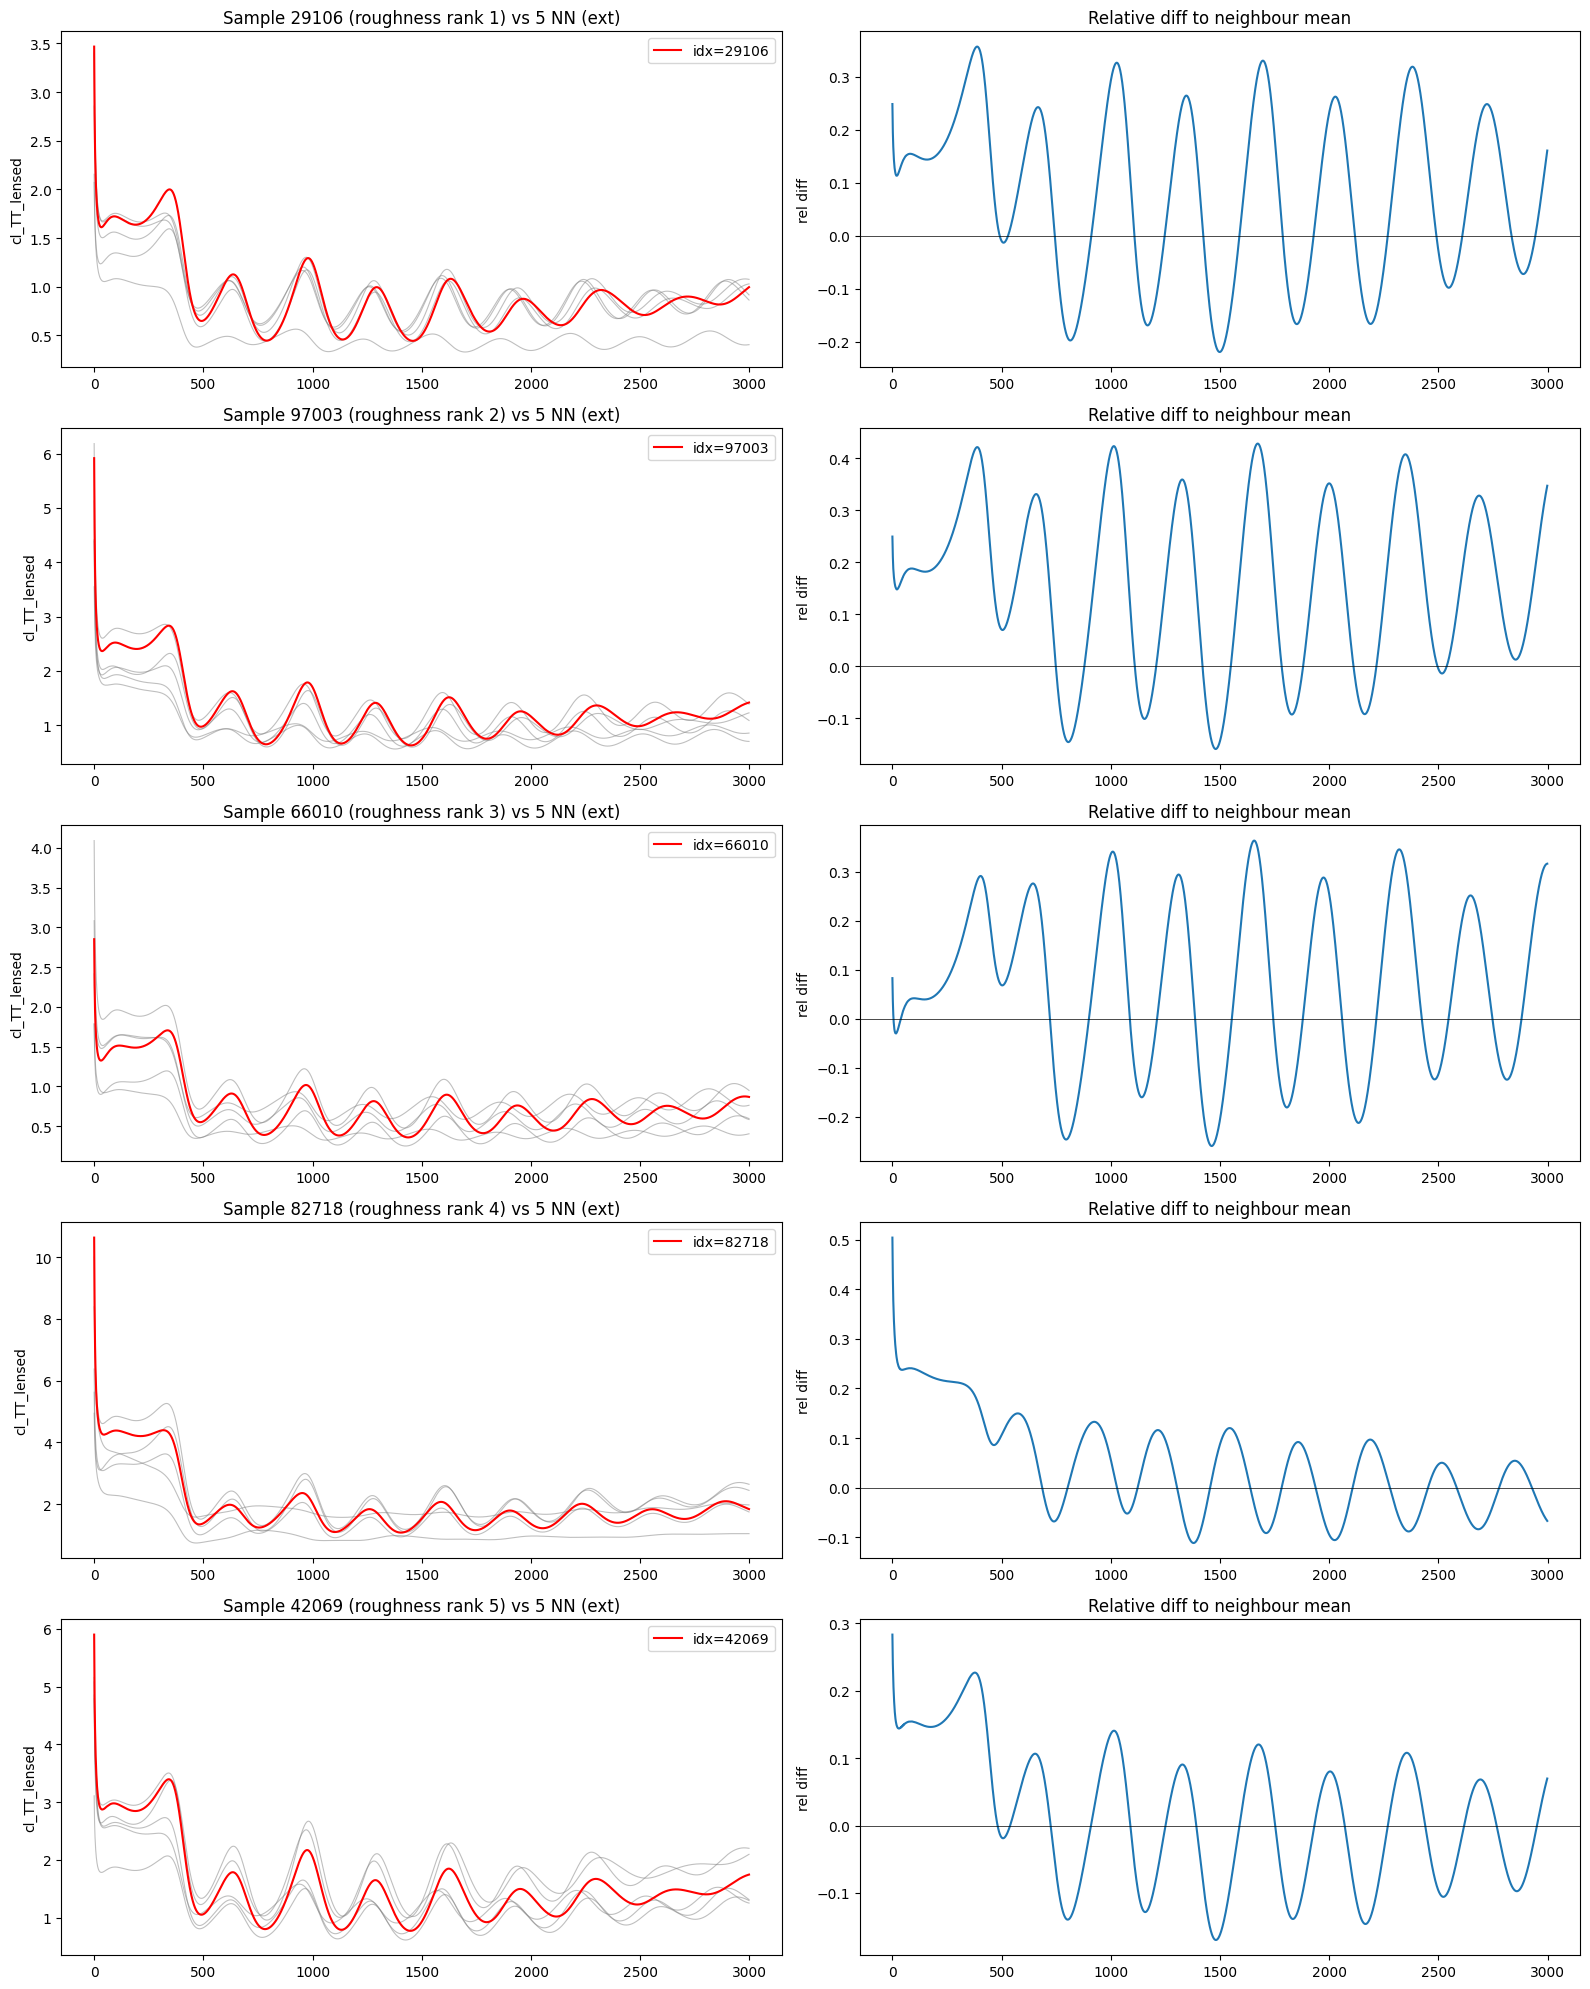

In [25]:
# Step 2: Roughest spectra vs neighbours
x_mean_ext = np.mean(x_ext, axis=0)
x_scale_ext = np.std(x_ext, axis=0)
x_norm_ext = (x_ext - x_mean_ext) / x_scale_ext
tree_ext = KDTree(x_norm_ext)

n_worst = 5
worst_idxs_ext = np.argsort(rel_roughness_ext)[-n_worst:][::-1]
k_neighbours = 5

fig, axs = plt.subplots(n_worst, 2, figsize=(16, 4*n_worst))
for i, idx in enumerate(worst_idxs_ext):
    dists_e, nn_idxs_e = tree_ext.query(x_norm_ext[idx], k=k_neighbours+1)
    nn_idxs_e = nn_idxs_e[1:]
    for nn in nn_idxs_e:
        axs[i, 0].plot(y_ext[nn], color='gray', alpha=0.5, lw=0.8)
    axs[i, 0].plot(y_ext[idx], color='red', lw=1.5, label=f'idx={idx}')
    axs[i, 0].set_title(f'Sample {idx} (roughness rank {i+1}) vs {k_neighbours} NN (ext)')
    axs[i, 0].legend()
    axs[i, 0].set_ylabel(spectrum)
    nn_mean_e = np.mean(y_ext[nn_idxs_e], axis=0)
    rel_diff_e = y_ext[idx] / nn_mean_e - 1.
    axs[i, 1].plot(rel_diff_e)
    axs[i, 1].set_title('Relative diff to neighbour mean')
    axs[i, 1].set_ylabel('rel diff')
    axs[i, 1].axhline(0, c='k', lw=0.5)
plt.tight_layout()
plt.show()

Top 100 worst emulator errors: overlap with top 100 roughest = 2


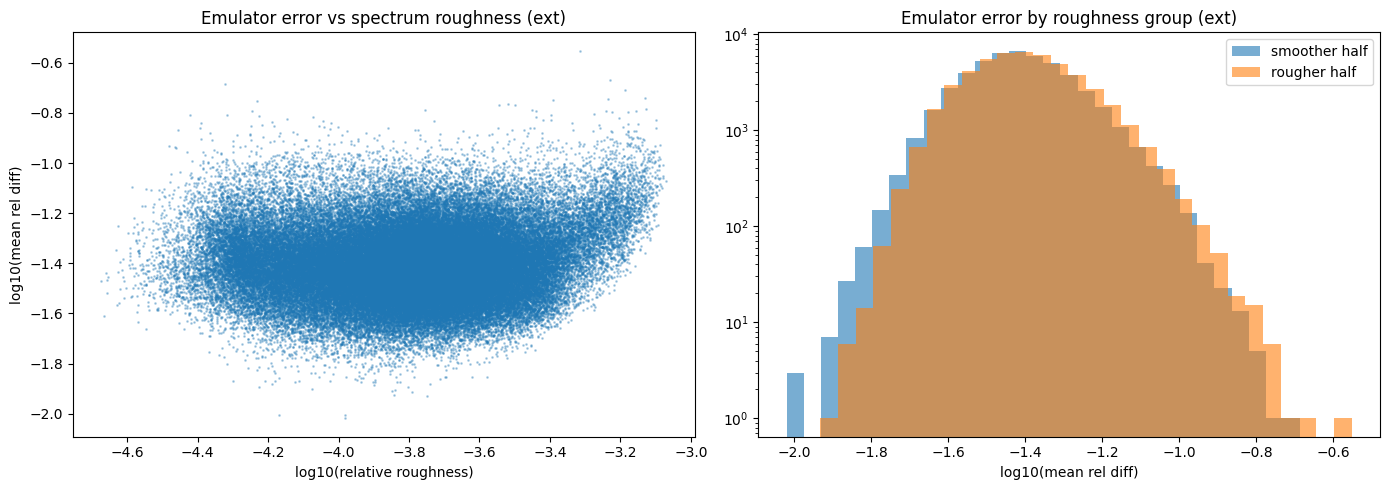

In [28]:
# Step 3: Emulator error vs roughness
emudata_ext = EmuData(emu_root)
mean_rel_ext = emudata_ext.get_mean_rel_diff(
    x_emu=x_ext, y_data=y_ext,
    want_scaling=False, want_pca=False, time_emu=False)

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].scatter(np.log10(rel_roughness_ext), np.log10(mean_rel_ext), s=1, alpha=0.3)
axs[0].set_xlabel('log10(relative roughness)')
axs[0].set_ylabel('log10(mean rel diff)')
axs[0].set_title('Emulator error vs spectrum roughness (ext)')

n_check = 100
worst_emu_ext = set(np.argsort(mean_rel_ext)[-n_check:])
worst_rough_ext = set(np.argsort(rel_roughness_ext)[-n_check:])
overlap_ext = worst_emu_ext & worst_rough_ext
print(f"Top {n_check} worst emulator errors: overlap with top {n_check} roughest = {len(overlap_ext)}")

median_roughness_ext = np.median(rel_roughness_ext)
mask_smooth_ext = rel_roughness_ext <= median_roughness_ext
mask_rough_ext = rel_roughness_ext > median_roughness_ext
axs[1].hist(np.log10(mean_rel_ext[mask_smooth_ext]), bins=30, alpha=0.6, label='smoother half', log=True)
axs[1].hist(np.log10(mean_rel_ext[mask_rough_ext]), bins=30, alpha=0.6, label='rougher half', log=True)
axs[1].set_xlabel('log10(mean rel diff)')
axs[1].set_title('Emulator error by roughness group (ext)')
axs[1].legend()
plt.tight_layout()
plt.show()

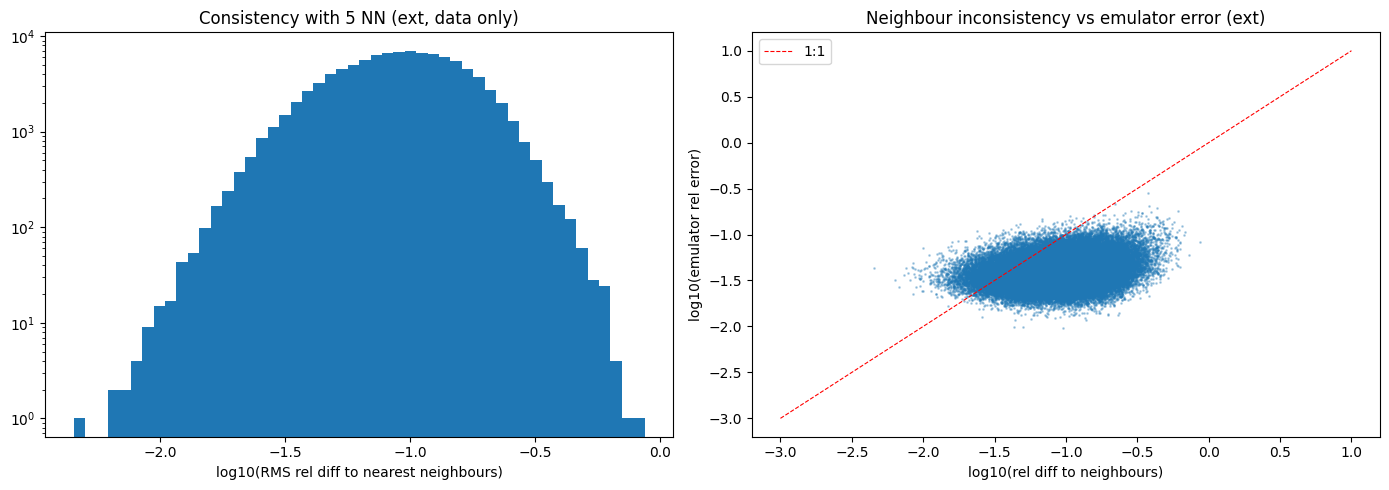

Samples deviating >99th pctile from neighbours: 1000
Threshold: 3.1410e-01
Worst 10 indices: [  796 47712 69756 29985 30786 84124 40511 36596 84912 67531]


In [29]:
# Step 4: Nearest-neighbour consistency (data-only)
k_nn = 5
dists_ext, nn_all_ext = tree_ext.query(x_norm_ext, k=k_nn+1)
nn_all_ext = nn_all_ext[:, 1:]
nn_mean_spectra_ext = np.mean(y_ext[nn_all_ext], axis=1)
rel_dev_nn_ext = np.sqrt(np.mean((y_ext / nn_mean_spectra_ext - 1.)**2, axis=1))

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].hist(np.log10(rel_dev_nn_ext), bins=50, log=True)
axs[0].set_xlabel('log10(RMS rel diff to nearest neighbours)')
axs[0].set_title(f'Consistency with {k_nn} NN (ext, data only)')

axs[1].scatter(np.log10(rel_dev_nn_ext), np.log10(mean_rel_ext), s=1, alpha=0.3)
axs[1].set_xlabel('log10(rel diff to neighbours)')
axs[1].set_ylabel('log10(emulator rel error)')
axs[1].set_title('Neighbour inconsistency vs emulator error (ext)')
axs[1].plot([-3, 1], [-3, 1], 'r--', lw=0.8, label='1:1')
axs[1].legend()
plt.tight_layout()
plt.show()

threshold_nn_ext = np.percentile(rel_dev_nn_ext, 99)
suspicious_ext = np.where(rel_dev_nn_ext > threshold_nn_ext)[0]
print(f"Samples deviating >99th pctile from neighbours: {len(suspicious_ext)}")
print(f"Threshold: {threshold_nn_ext:.4e}")
print(f"Worst 10 indices: {np.argsort(rel_dev_nn_ext)[-10:][::-1]}")

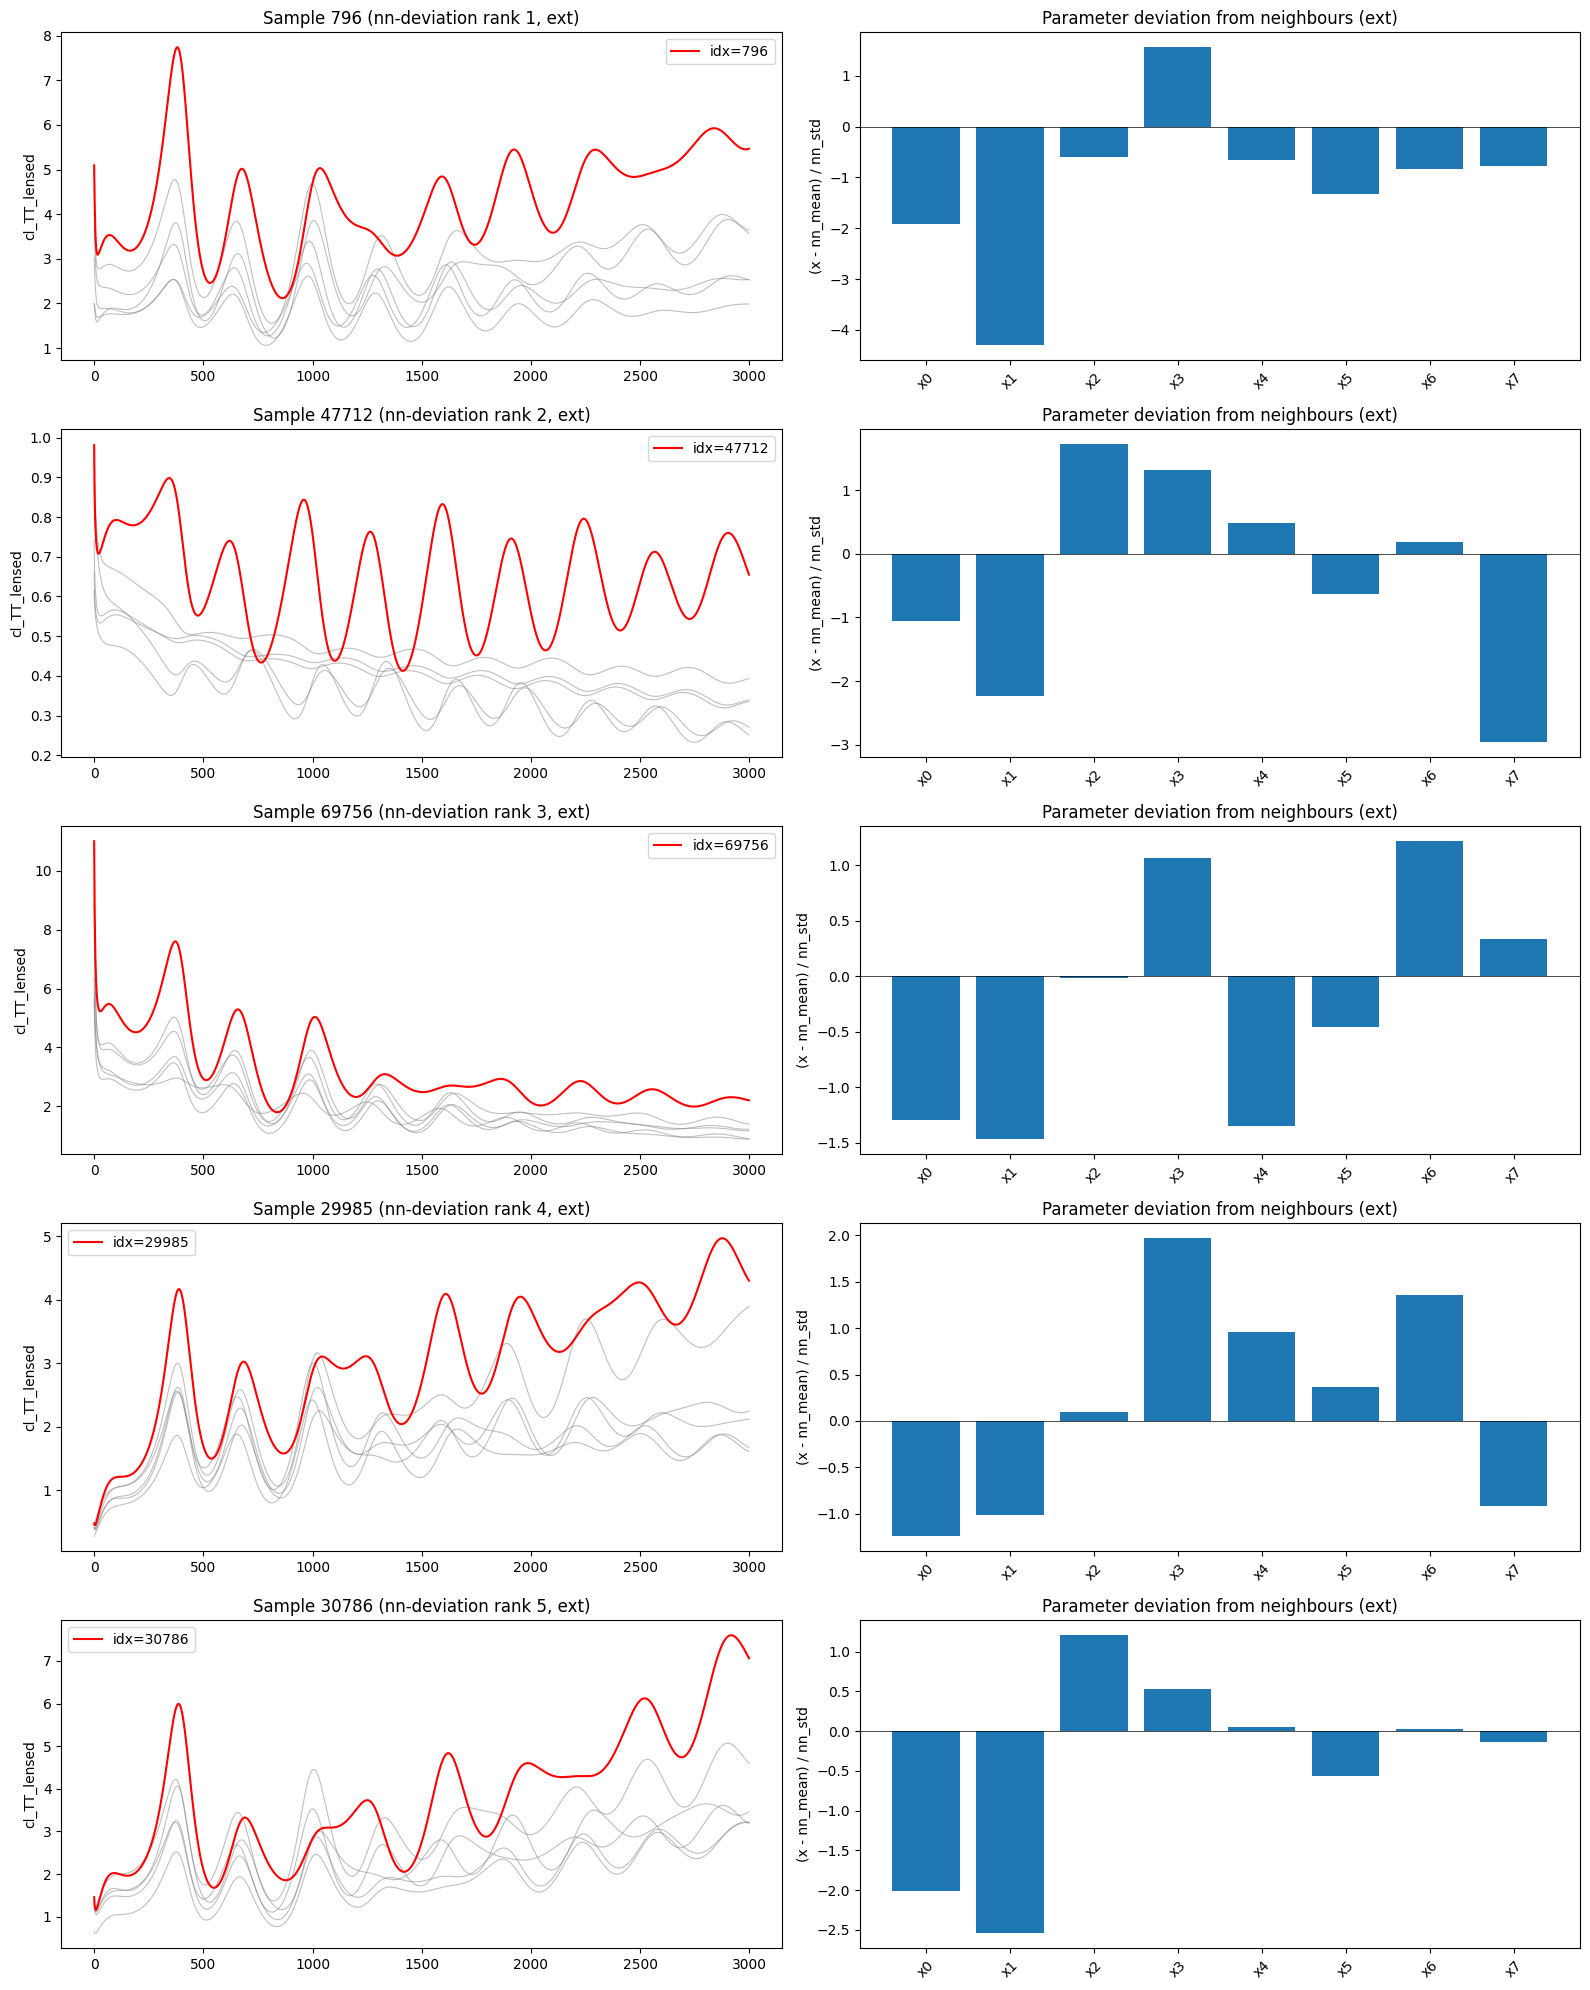

In [30]:
# Step 5: Most suspicious samples
n_show = 5
worst_nn_idxs_ext = np.argsort(rel_dev_nn_ext)[-n_show:][::-1]
fig, axs = plt.subplots(n_show, 2, figsize=(16, 4*n_show))
for i, idx in enumerate(worst_nn_idxs_ext):
    nn_idxs_e = nn_all_ext[idx]
    for nn in nn_idxs_e:
        axs[i, 0].plot(y_ext[nn], color='gray', alpha=0.5, lw=0.8)
    axs[i, 0].plot(y_ext[idx], color='red', lw=1.5, label=f'idx={idx}')
    axs[i, 0].set_title(f'Sample {idx} (nn-deviation rank {i+1}, ext)')
    axs[i, 0].legend()
    axs[i, 0].set_ylabel(spectrum)
    x_params_e = x_ext[idx]
    x_nn_params_e = x_ext[nn_idxs_e]
    x_labels = [f'x{j}' for j in range(x_ext.shape[1])]
    x_nn_mean_e = np.mean(x_nn_params_e, axis=0)
    x_nn_std_e = np.std(x_nn_params_e, axis=0)
    x_nn_std_e[x_nn_std_e == 0] = 1.
    deviation_e = (x_params_e - x_nn_mean_e) / x_nn_std_e
    axs[i, 1].bar(range(len(deviation_e)), deviation_e)
    axs[i, 1].set_xticks(range(len(x_labels)))
    axs[i, 1].set_xticklabels(x_labels, rotation=45)
    axs[i, 1].set_title('Parameter deviation from neighbours (ext)')
    axs[i, 1].set_ylabel('(x - nn_mean) / nn_std')
    axs[i, 1].axhline(0, c='k', lw=0.5)
plt.tight_layout()
plt.show()

In [31]:
# Step 6: Worst points table (ext)
x_names = emudata_ext.emu.x_names
n_top = 10
worst_emu_idxs_ext = np.argsort(mean_rel_ext)[-n_top:][::-1]

print(f"Parameter names: {x_names}\n")
print(f"{'Rank':<5} {'Index':<8} {'Mean rel err':<14} {'NN dev':<14} {'Roughness':<14} | {('  '.join([f'{n:>12s}' for n in x_names]))}")
print("-" * (55 + 14*len(x_names)))
for rank, idx in enumerate(worst_emu_idxs_ext):
    vals = '  '.join([f'{v:12.5e}' for v in x_ext[idx]])
    print(f"{rank+1:<5} {idx:<8} {mean_rel_ext[idx]:<14.4e} {rel_dev_nn_ext[idx]:<14.4e} {rel_roughness_ext[idx]:<14.4e} | {vals}")

Parameter names: ['h', 'Omega_m', 'Omega_b', 'ln_A_s_1e10', 'n_s', 'tau_reio', 'N_ur', 'm_ncdm']

Rank  Index    Mean rel err   NN dev         Roughness      |            h       Omega_m       Omega_b   ln_A_s_1e10           n_s      tau_reio          N_ur        m_ncdm
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
1     91171    2.8080e-01     3.7846e-01     4.8434e-04     |  8.43216e-01   1.81766e-01   3.89746e-02   2.07187e+00   7.81118e-01   1.67099e-01   1.70418e+00   2.62399e-01
2     25551    2.1553e-01     2.1911e-01     5.8953e-04     |  5.15935e-01   1.54663e-01   6.89165e-02   2.19550e+00   7.68517e-01   1.40256e-01   1.82646e+00   1.63422e-01
3     88830    2.0601e-01     3.8463e-01     4.7609e-05     |  5.05111e-01   1.52709e-01   6.08911e-02   3.42008e+00   1.22001e+00   6.07755e-02   1.83807e+00   1.30492e-01
4     31105    1.9538e-01     4.3136e-01  

## Cross-dataset comparison

In [34]:
# ========== Cross-dataset comparison ==========
import numpy as np

datasets = {
    'thin': {'mean_rel': mean_rel_thin, 'roughness': rel_roughness_thin, 'nn_dev': rel_dev_nn_thin, 'x': x_thin, 'y': y_thin},
    'std':  {'mean_rel': mean_rel,      'roughness': rel_roughness,      'nn_dev': rel_dev_nn,      'x': x_std,  'y': y_std},
    'ext':  {'mean_rel': mean_rel_ext,  'roughness': rel_roughness_ext,  'nn_dev': rel_dev_nn_ext,  'x': x_ext,  'y': y_ext},
}

# --- Data quality ---
print("=== Data quality ===")
print(f"{'Dataset':<8} {'N samples':<10} {'NaN in y':<10} {'NaN in emu err':<16} {'NaN in roughness':<18} {'NaN in nn_dev'}")
for name, d in datasets.items():
    print(f"{name:<8} {len(d['mean_rel']):<10} {np.isnan(d['y']).sum():<10} {np.isnan(d['mean_rel']).sum():<16} {np.isnan(d['roughness']).sum():<18} {np.isnan(d['nn_dev']).sum()}")

# --- Emulator error (using nanpercentile to handle NaN) ---
print("\n=== Emulator error quantiles ===")
print(f"{'Pctile':<8} {'thin':<14} {'std':<14} {'ext':<14} {'ext/thin':<10} {'std/thin':<10}")
for pct in [50, 90, 95, 99]:
    vals = {name: np.nanpercentile(d['mean_rel'], pct) for name, d in datasets.items()}
    print(f"P{pct:<7} {vals['thin']:<14.4e} {vals['std']:<14.4e} {vals['ext']:<14.4e} {vals['ext']/vals['thin']:<10.2f} {vals['std']/vals['thin']:<10.2f}")

# --- Roughness ---
print("\n=== Data roughness quantiles (relative) ===")
print(f"{'Pctile':<8} {'thin':<14} {'std':<14} {'ext':<14} {'ext/thin':<10}")
for pct in [50, 90, 99]:
    vals = {name: np.nanpercentile(d['roughness'], pct) for name, d in datasets.items()}
    print(f"P{pct:<7} {vals['thin']:<14.4e} {vals['std']:<14.4e} {vals['ext']:<14.4e} {vals['ext']/vals['thin']:<10.2f}")

# --- NN deviation ---
print("\n=== NN deviation quantiles ===")
print(f"{'Pctile':<8} {'thin':<14} {'std':<14} {'ext':<14} {'ext/thin':<10}")
for pct in [50, 90, 99]:
    vals = {name: np.nanpercentile(d['nn_dev'], pct) for name, d in datasets.items()}
    print(f"P{pct:<7} {vals['thin']:<14.4e} {vals['std']:<14.4e} {vals['ext']:<14.4e} {vals['ext']/vals['thin']:<10.2f}")

# --- Roughness-error overlap ---
print("\n=== Roughness vs emulator error overlap (top 100) ===")
for name, d in datasets.items():
    mr = d['mean_rel']
    rr = d['roughness']
    n_check = 100
    overlap = len(set(np.argsort(mr)[-n_check:]) & set(np.argsort(rr)[-n_check:]))
    print(f"  {name}: {overlap}/100")

=== Data quality ===
Dataset  N samples  NaN in y   NaN in emu err   NaN in roughness   NaN in nn_dev
thin     100000     5998       2                2                  10
std      100000     0          0                0                  0
ext      100000     0          0                0                  0

=== Emulator error quantiles ===
Pctile   thin           std            ext            ext/thin   std/thin  
P50      9.2376e-03     2.4391e-02     3.8853e-02     4.21       2.64      
P90      1.1733e-02     3.6847e-01     6.0411e-02     5.15       31.40     
P95      1.2475e-02     4.8503e-01     6.9675e-02     5.59       38.88     
P99      1.3689e-02     8.2071e-01     9.2469e-02     6.76       59.95     

=== Data roughness quantiles (relative) ===
Pctile   thin           std            ext            ext/thin  
P50      8.2609e-05     1.1763e-04     1.6471e-04     1.99      
P90      1.0631e-04     2.9626e-04     3.4070e-04     3.20      
P99      1.2884e-04     4.4520e-04  

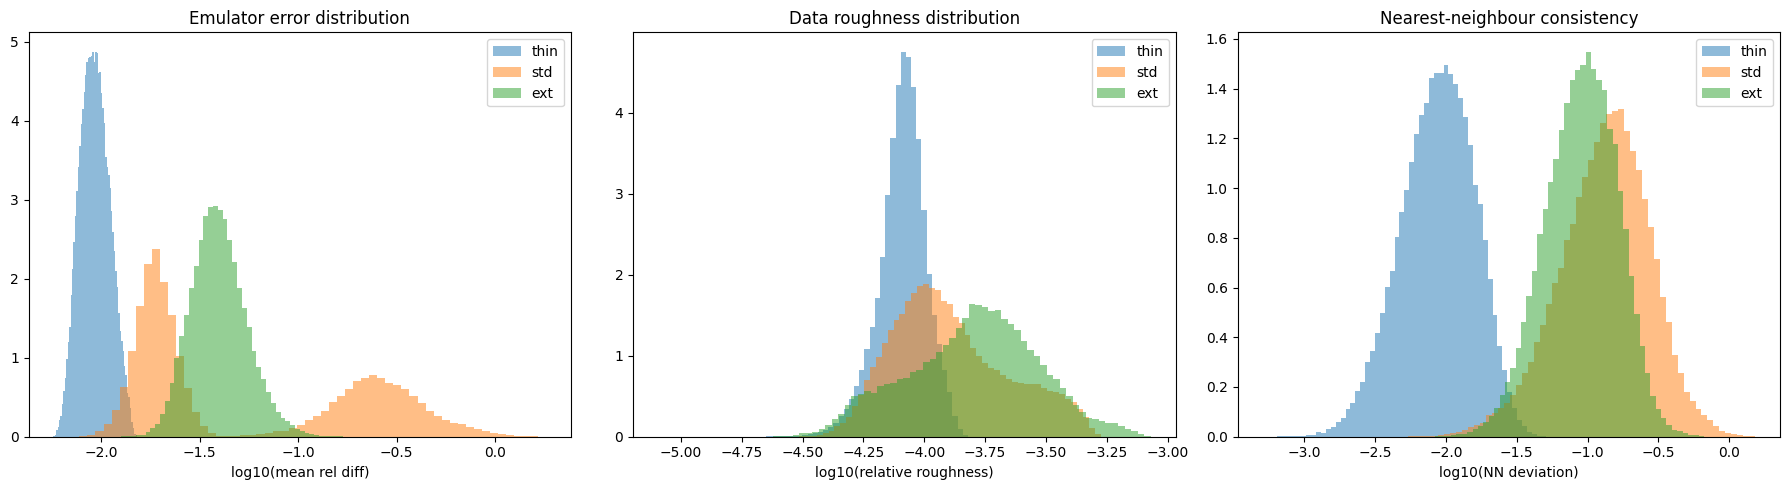

In [35]:
# Side-by-side comparison plots
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# 1) Emulator error histograms
for name, d in datasets.items():
    mr = d['mean_rel']
    mr = mr[np.isfinite(mr)]
    axs[0].hist(np.log10(mr), bins=60, alpha=0.5, label=name, density=True)
axs[0].set_xlabel('log10(mean rel diff)')
axs[0].set_title('Emulator error distribution')
axs[0].legend()

# 2) Roughness histograms
for name, d in datasets.items():
    rr = d['roughness']
    rr = rr[np.isfinite(rr)]
    axs[1].hist(np.log10(rr), bins=60, alpha=0.5, label=name, density=True)
axs[1].set_xlabel('log10(relative roughness)')
axs[1].set_title('Data roughness distribution')
axs[1].legend()

# 3) NN deviation histograms
for name, d in datasets.items():
    nn = d['nn_dev']
    nn = nn[np.isfinite(nn)]
    axs[2].hist(np.log10(nn), bins=60, alpha=0.5, label=name, density=True)
axs[2].set_xlabel('log10(NN deviation)')
axs[2].set_title('Nearest-neighbour consistency')
axs[2].legend()

plt.tight_layout()
plt.show()

Good population (err < 0.1): 59637 samples
Bad population  (err >= 0.1): 40363 samples


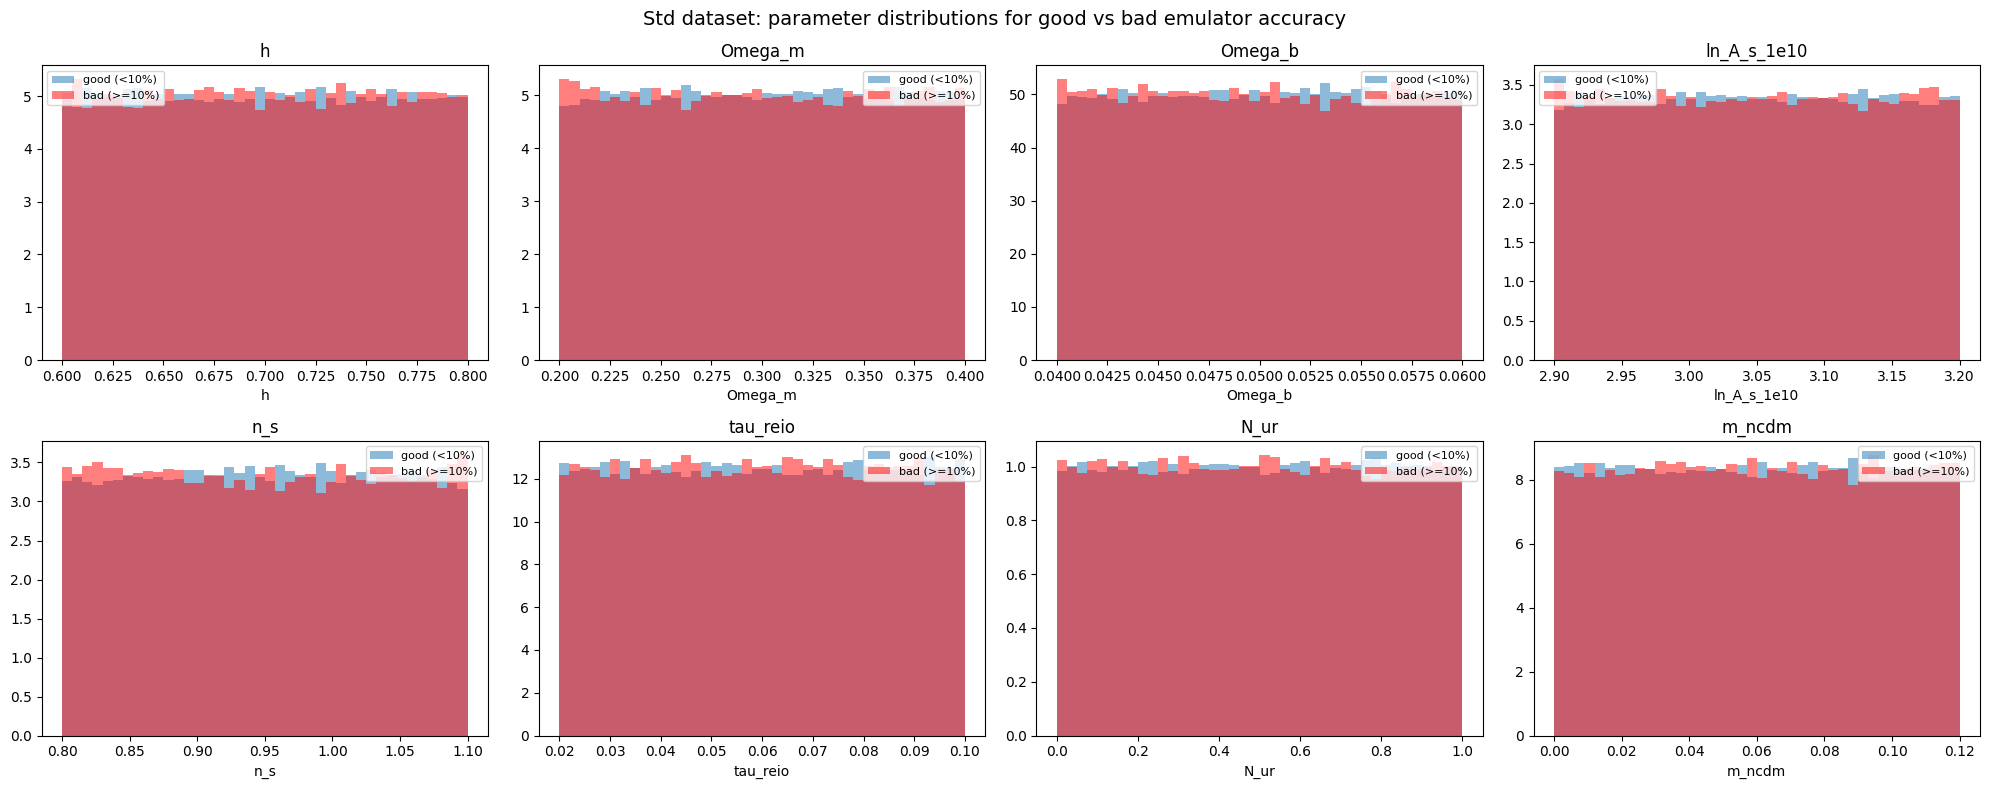


Single-parameter separation power (AUC of bad vs good):
                     h:  AUC = 0.5012  (1.0 = perfect, 0.5 = useless)
               Omega_m:  AUC = 0.4978  (1.0 = perfect, 0.5 = useless)
               Omega_b:  AUC = 0.4965  (1.0 = perfect, 0.5 = useless)
           ln_A_s_1e10:  AUC = 0.4992  (1.0 = perfect, 0.5 = useless)
                   n_s:  AUC = 0.4972  (1.0 = perfect, 0.5 = useless)
              tau_reio:  AUC = 0.4991  (1.0 = perfect, 0.5 = useless)
                  N_ur:  AUC = 0.4982  (1.0 = perfect, 0.5 = useless)
                m_ncdm:  AUC = 0.5019  (1.0 = perfect, 0.5 = useless)

Best single separator: Omega_b (AUC=0.4965)


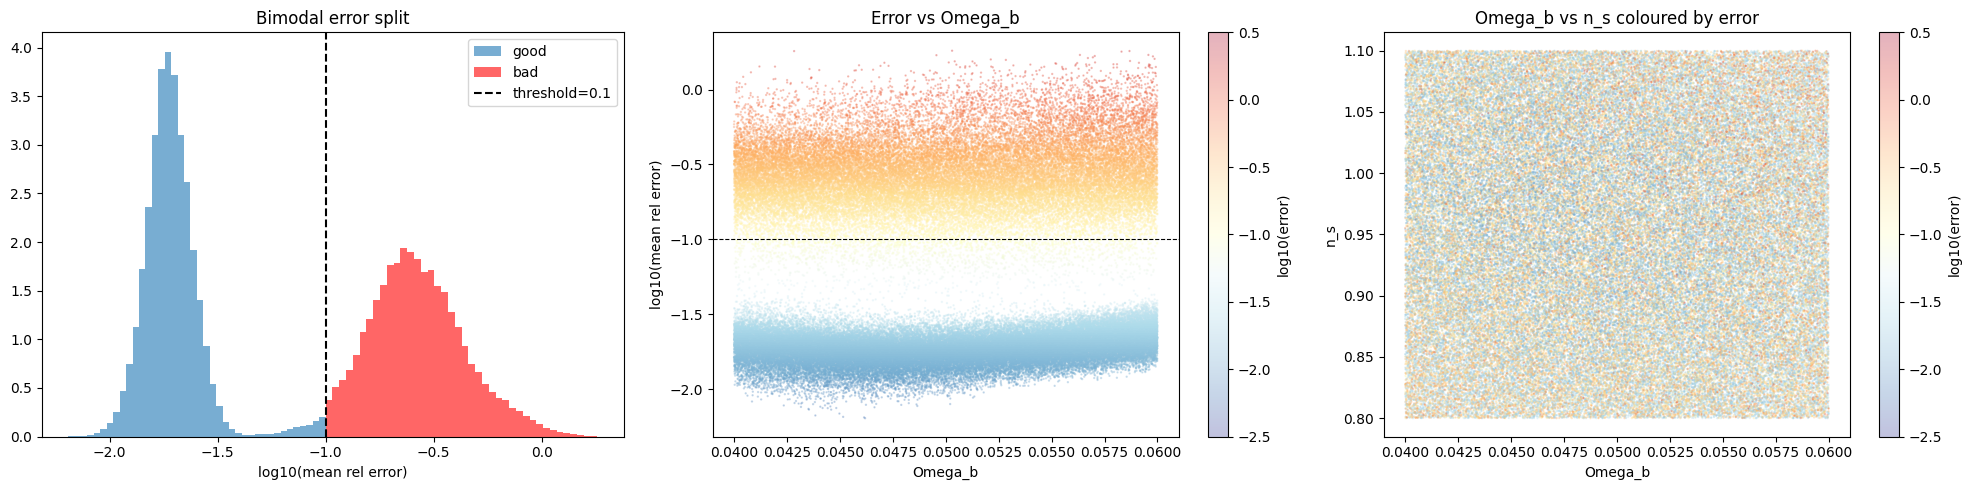

In [37]:
# ========== Understanding the bimodality: which parameters separate the two populations? ==========
x_names = emudata_check.emu.x_names

# Split std into "good" and "bad" populations using a threshold from the valley of the bimodal histogram
# The valley is roughly at log10(mean_rel) ~ -1.0, i.e. mean_rel ~ 0.1
err_threshold = 0.1
good_mask = mean_rel < err_threshold
bad_mask = mean_rel >= err_threshold
print(f"Good population (err < {err_threshold}): {good_mask.sum()} samples")
print(f"Bad population  (err >= {err_threshold}): {bad_mask.sum()} samples")

# --- 1) Parameter distributions for good vs bad ---
n_params = x_std.shape[1]
fig, axs = plt.subplots(2, 4, figsize=(20, 8))
axs = axs.ravel()
for ip in range(n_params):
    axs[ip].hist(x_std[good_mask, ip], bins=40, alpha=0.5, label='good (<10%)', density=True)
    axs[ip].hist(x_std[bad_mask, ip], bins=40, alpha=0.5, label='bad (>=10%)', density=True, color='red')
    axs[ip].set_xlabel(x_names[ip])
    axs[ip].set_title(x_names[ip])
    axs[ip].legend(fontsize=8)
for ip in range(n_params, len(axs)):
    axs[ip].set_visible(False)
fig.suptitle('Std dataset: parameter distributions for good vs bad emulator accuracy', fontsize=14)
plt.tight_layout()
plt.show()

# --- 2) Single best separator: check each parameter individually ---
from sklearn.metrics import roc_auc_score
print("\nSingle-parameter separation power (AUC of bad vs good):")
labels = bad_mask.astype(int)
for ip in range(n_params):
    auc = roc_auc_score(labels, x_std[:, ip])
    print(f"  {x_names[ip]:>20s}:  AUC = {auc:.4f}  (1.0 = perfect, 0.5 = useless)")

# --- 3) Scatter: emulator error coloured by the most separating parameter ---
# Identify the best separator
aucs = [roc_auc_score(labels, x_std[:, ip]) for ip in range(n_params)]
best_ip = np.argmax([abs(a - 0.5) for a in aucs])
best_name = x_names[best_ip]
print(f"\nBest single separator: {best_name} (AUC={aucs[best_ip]:.4f})")

fig, axs = plt.subplots(1, 3, figsize=(20, 5))

# Error histogram with the split
axs[0].hist(np.log10(mean_rel[good_mask]), bins=40, alpha=0.6, label='good', density=True)
axs[0].hist(np.log10(mean_rel[bad_mask]), bins=40, alpha=0.6, label='bad', density=True, color='red')
axs[0].axvline(np.log10(err_threshold), c='k', ls='--', label=f'threshold={err_threshold}')
axs[0].set_xlabel('log10(mean rel error)')
axs[0].set_title('Bimodal error split')
axs[0].legend()

# Best parameter vs emulator error
sc = axs[1].scatter(x_std[:, best_ip], np.log10(mean_rel), c=np.log10(mean_rel),
                     s=0.5, alpha=0.3, cmap='RdYlBu_r', vmin=-2.5, vmax=0.5)
axs[1].set_xlabel(best_name)
axs[1].set_ylabel('log10(mean rel error)')
axs[1].set_title(f'Error vs {best_name}')
axs[1].axhline(np.log10(err_threshold), c='k', ls='--', lw=0.8)
plt.colorbar(sc, ax=axs[1], label='log10(error)')

# Parameter-parameter scatter coloured by error
# Find second best separator
aucs_rank = np.argsort([abs(a - 0.5) for a in aucs])[::-1]
best2_ip = aucs_rank[1]
best2_name = x_names[best2_ip]
sc2 = axs[2].scatter(x_std[:, best_ip], x_std[:, best2_ip], c=np.log10(mean_rel),
                      s=0.5, alpha=0.3, cmap='RdYlBu_r', vmin=-2.5, vmax=0.5)
axs[2].set_xlabel(best_name)
axs[2].set_ylabel(best2_name)
axs[2].set_title(f'{best_name} vs {best2_name} coloured by error')
plt.colorbar(sc2, ax=axs[2], label='log10(error)')

plt.tight_layout()
plt.show()

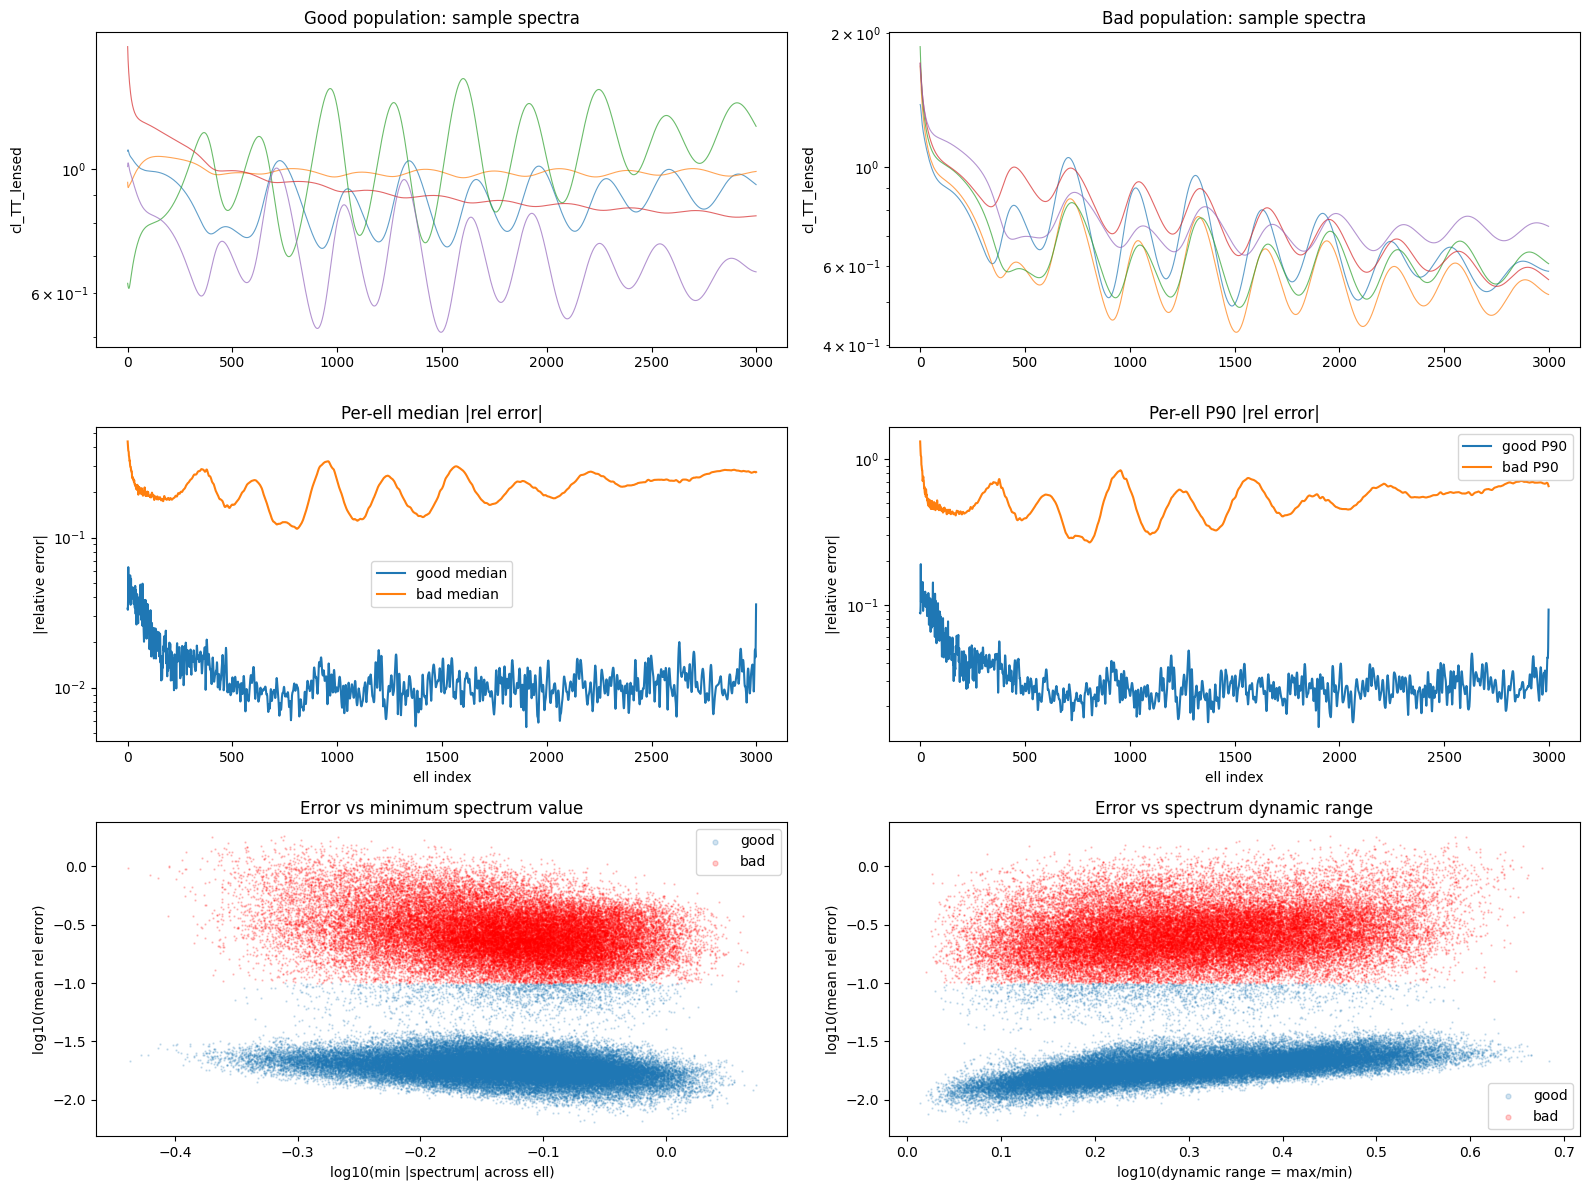

Separation power of spectral features:
  min(|y|)       AUC = 0.4920
  mean(|y|)      AUC = 0.4988
  dynamic range  AUC = 0.5092


In [38]:
# ========== Diagnosing the bimodality: is it about relative error blow-up? ==========

# Get the full relative difference (not just the mean) for a few good and bad samples
good_idxs = np.where(good_mask)[0][:5]
bad_idxs = np.argsort(mean_rel)[-5:][::-1]

fig, axs = plt.subplots(3, 2, figsize=(16, 12))

# Row 1: Sample spectra from each population
for idx in good_idxs:
    axs[0, 0].plot(y_std[idx], alpha=0.7, lw=0.8)
axs[0, 0].set_title('Good population: sample spectra')
axs[0, 0].set_ylabel(spectrum)
axs[0, 0].set_yscale('log')
for idx in bad_idxs:
    axs[0, 1].plot(y_std[idx], alpha=0.7, lw=0.8)
axs[0, 1].set_title('Bad population: sample spectra')
axs[0, 1].set_ylabel(spectrum)
axs[0, 1].set_yscale('log')

# Row 2: Per-ell relative error for good vs bad
rel_diff_good = emudata_check.rel_diff[good_mask]  # already computed
rel_diff_bad = emudata_check.rel_diff[bad_mask]
median_reldiff_good = np.median(np.abs(rel_diff_good), axis=0)
median_reldiff_bad = np.median(np.abs(rel_diff_bad), axis=0)
p90_reldiff_good = np.percentile(np.abs(rel_diff_good), 90, axis=0)
p90_reldiff_bad = np.percentile(np.abs(rel_diff_bad), 90, axis=0)

axs[1, 0].plot(median_reldiff_good, label='good median')
axs[1, 0].plot(median_reldiff_bad, label='bad median')
axs[1, 0].set_yscale('log')
axs[1, 0].set_xlabel('ell index')
axs[1, 0].set_ylabel('|relative error|')
axs[1, 0].set_title('Per-ell median |rel error|')
axs[1, 0].legend()

axs[1, 1].plot(p90_reldiff_good, label='good P90')
axs[1, 1].plot(p90_reldiff_bad, label='bad P90')
axs[1, 1].set_yscale('log')
axs[1, 1].set_xlabel('ell index')
axs[1, 1].set_ylabel('|relative error|')
axs[1, 1].set_title('Per-ell P90 |rel error|')
axs[1, 1].legend()

# Row 3: Check if it's about the minimum spectrum value
min_y_std = np.min(np.abs(y_std), axis=1)
mean_y_std = np.mean(np.abs(y_std), axis=1)
max_y_std = np.max(np.abs(y_std), axis=1)
dyn_range = max_y_std / min_y_std

axs[2, 0].scatter(np.log10(min_y_std[good_mask]), np.log10(mean_rel[good_mask]), s=0.5, alpha=0.2, label='good')
axs[2, 0].scatter(np.log10(min_y_std[bad_mask]), np.log10(mean_rel[bad_mask]), s=0.5, alpha=0.2, label='bad', c='red')
axs[2, 0].set_xlabel('log10(min |spectrum| across ell)')
axs[2, 0].set_ylabel('log10(mean rel error)')
axs[2, 0].set_title('Error vs minimum spectrum value')
axs[2, 0].legend(markerscale=5)

axs[2, 1].scatter(np.log10(dyn_range[good_mask]), np.log10(mean_rel[good_mask]), s=0.5, alpha=0.2, label='good')
axs[2, 1].scatter(np.log10(dyn_range[bad_mask]), np.log10(mean_rel[bad_mask]), s=0.5, alpha=0.2, label='bad', c='red')
axs[2, 1].set_xlabel('log10(dynamic range = max/min)')
axs[2, 1].set_ylabel('log10(mean rel error)')
axs[2, 1].set_title('Error vs spectrum dynamic range')
axs[2, 1].legend(markerscale=5)

plt.tight_layout()
plt.show()

# AUC for spectral features
min_auc = roc_auc_score(labels, min_y_std)
dyn_auc = roc_auc_score(labels, dyn_range)
mean_auc = roc_auc_score(labels, mean_y_std)
print(f"Separation power of spectral features:")
print(f"  min(|y|)       AUC = {min_auc:.4f}")
print(f"  mean(|y|)      AUC = {mean_auc:.4f}")
print(f"  dynamic range  AUC = {dyn_auc:.4f}")

PCA components: 360
PCA type: <class 'emu_like.pca.PCA'>
PCA attributes: ['export', 'fit', 'inverse_transform', 'load', 'n_components', 'pca', 'save', 'transform']


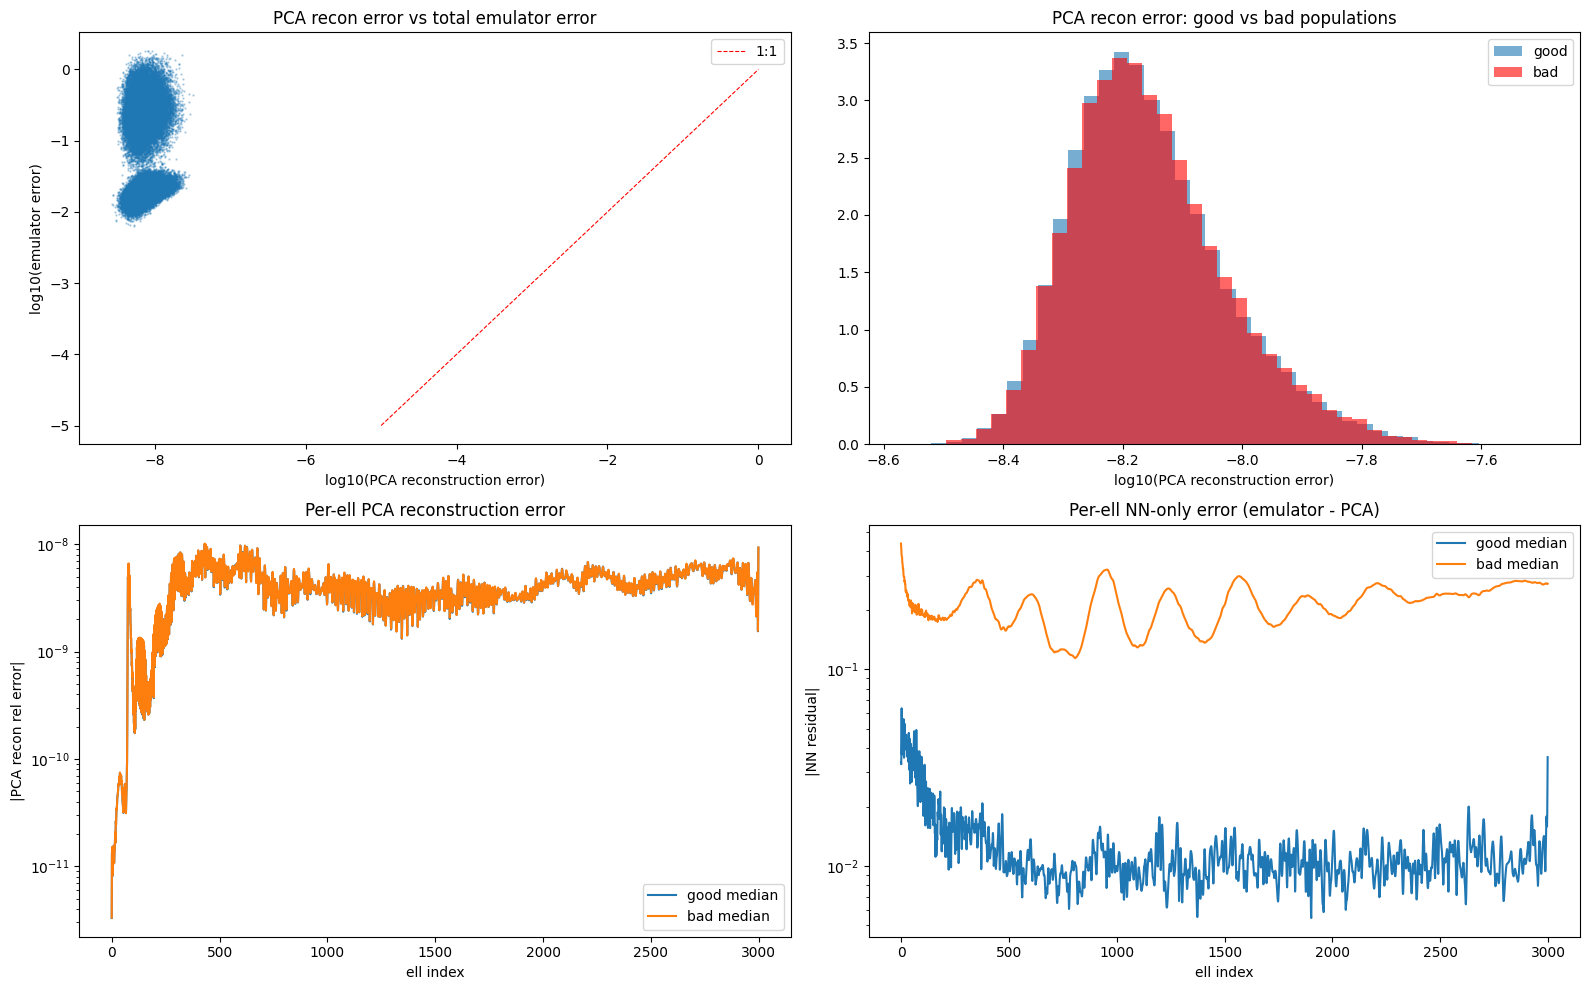


PCA reconstruction error AUC: 0.5049
=> PCA truncation is NOT the separator either.


In [40]:
# ========== Is it PCA truncation? ==========
# Check the PCA reconstruction error (roundtrip through PCA) vs the full emulator error

y_pca = emudata_check.emu.y_pca
y_scaler = emudata_check.emu.y_scaler

# Apply the same pipeline: scale, PCA, inverse PCA, inverse scale
if y_scaler is not None:
    y_scaled = y_scaler.transform(y_std)
else:
    y_scaled = y_std.copy()

if y_pca is not None:
    y_pca_proj = y_pca.transform(y_scaled)
    y_reconstructed_scaled = y_pca.inverse_transform(y_pca_proj)
    n_pca = y_pca.n_components
    print(f"PCA components: {n_pca}")
    # Check for explained_variance_ratio_ or singular_values_
    if hasattr(y_pca, 'explained_variance_ratio_'):
        print(f"Total explained variance: {np.sum(y_pca.explained_variance_ratio_)*100:.4f}%")
    elif hasattr(y_pca, 'singular_values_'):
        sv = y_pca.singular_values_
        print(f"Singular values range: {sv[0]:.2e} to {sv[-1]:.2e}, ratio = {sv[0]/sv[-1]:.1f}")
    print(f"PCA type: {type(y_pca)}")
    print(f"PCA attributes: {[a for a in dir(y_pca) if not a.startswith('_')]}")
else:
    y_reconstructed_scaled = y_scaled
    print("No PCA used")

if y_scaler is not None:
    y_reconstructed = y_scaler.inverse_transform(y_reconstructed_scaled)
else:
    y_reconstructed = y_reconstructed_scaled

# PCA reconstruction error (relative)
pca_rel_err = y_reconstructed / y_std - 1.
mean_pca_rel_err = np.sqrt(np.mean(pca_rel_err**2, axis=1))

# Compare PCA reconstruction error to emulator error
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

# Scatter: PCA recon error vs emulator error
axs[0, 0].scatter(np.log10(mean_pca_rel_err), np.log10(mean_rel), s=0.5, alpha=0.3)
axs[0, 0].plot([-5, 0], [-5, 0], 'r--', lw=0.8, label='1:1')
axs[0, 0].set_xlabel('log10(PCA reconstruction error)')
axs[0, 0].set_ylabel('log10(emulator error)')
axs[0, 0].set_title('PCA recon error vs total emulator error')
axs[0, 0].legend()

# Histogram of PCA recon error split by good/bad
axs[0, 1].hist(np.log10(mean_pca_rel_err[good_mask]), bins=40, alpha=0.6, label='good', density=True)
axs[0, 1].hist(np.log10(mean_pca_rel_err[bad_mask]), bins=40, alpha=0.6, label='bad', density=True, color='red')
axs[0, 1].set_xlabel('log10(PCA reconstruction error)')
axs[0, 1].set_title('PCA recon error: good vs bad populations')
axs[0, 1].legend()

# Per-ell PCA reconstruction error
median_pca_good = np.median(np.abs(pca_rel_err[good_mask]), axis=0)
median_pca_bad = np.median(np.abs(pca_rel_err[bad_mask]), axis=0)
axs[1, 0].plot(median_pca_good, label='good median')
axs[1, 0].plot(median_pca_bad, label='bad median')
axs[1, 0].set_yscale('log')
axs[1, 0].set_xlabel('ell index')
axs[1, 0].set_ylabel('|PCA recon rel error|')
axs[1, 0].set_title('Per-ell PCA reconstruction error')
axs[1, 0].legend()

# Per-ell NN-only error
median_nn_good = np.median(np.abs(emudata_check.rel_diff[good_mask] - pca_rel_err[good_mask]), axis=0)
median_nn_bad = np.median(np.abs(emudata_check.rel_diff[bad_mask] - pca_rel_err[bad_mask]), axis=0)
axs[1, 1].plot(median_nn_good, label='good median')
axs[1, 1].plot(median_nn_bad, label='bad median')
axs[1, 1].set_yscale('log')
axs[1, 1].set_xlabel('ell index')
axs[1, 1].set_ylabel('|NN residual|')
axs[1, 1].set_title('Per-ell NN-only error (emulator - PCA)')
axs[1, 1].legend()

plt.tight_layout()
plt.show()

# AUC for PCA recon error  
pca_auc = roc_auc_score(labels, mean_pca_rel_err)
print(f"\nPCA reconstruction error AUC: {pca_auc:.4f}")
print(f"=> {'PCA truncation IS the separator!' if abs(pca_auc - 0.5) > 0.1 else 'PCA truncation is NOT the separator either.'}")